In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
import simnibs
import sys
sys.path.insert(0, 'D:/MINDS_Project_Karim/BIDS_TI_Toolbox/code/pipeline')

PROJECT_DIR  = 'D:/MINDS_Project_Karim/BIDS_TI_Toolbox'
ALL_SUBJECTS = ['73T01', '73T02', '73T03', '73T04', '73T05', '73T06','73T07', '73T09', '73T10', '73T11', '73T12', '73T14']

CAP_NAME      = 'BioSemi32_MNE'      # used for registered electrode CSV
# LEADFIELD_PATH = None                 # None = auto-resolve from CAP_NAME
                                      # Set explicitly for non-standard paths, e.g.:
LEADFIELD_PATH = (
  f"{PROJECT_DIR}/derivatives/SimNIBS/sub-{{SUBJECT}}"
  "/leadfield_volume/EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm"
  "/{{SUBJECT}}_leadfield_EEG10-10_UI_Jurak_2007.hdf5"
)


# ── Single-subject selection ───────────────────────────────────────────────────
SUBJECT = '73T01'      # ← change this to switch subjects
GOAL    = 'focality'   # ← which pipeline result to load as Setup A

# ── Setup B — manual montage ──────────────────────────────────────────────────
SETUP_B = dict(
    ch1_plus='F8', ch1_minus='FC3', ch1_current_mA=1.9245,
    ch2_plus='P5',  ch2_minus='TP10', ch2_current_mA=1.9994,
    label='manual',
)

# -- Setup C - template montage (BioSemi64) ------------------------------------------------------
SETUP_C= dict(
    ch1_plus='FT7', ch1_minus='Fp2', ch1_current_mA=1.9245,
    ch2_plus='TP7',  ch2_minus='P8', ch2_current_mA=1.9994,
    label='template',
)


In [2]:
# ── Cell 2: Load pipeline best result (Setup A) ───────────────────────────────
import json, glob, os

def load_pipeline_result(subject, goal, project_dir):
    pattern = os.path.join(
        project_dir, 'derivatives', 'SimNIBS', f'sub-{subject}',
        'TIoptimization',
        # f'sub-{subject}_roi-hippo_r_phg_goal-ex_{goal}_job-*_run-*',
        f'sub-{subject}_roi-right_hc_phg_hierarchical_BNA_goal-ex_{goal}_job-*_run-*',
        'exhaustive_results.json'
    )
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f'No result found for sub-{subject} goal={goal}\n{pattern}')
    return json.load(open(matches[-1])), matches[-1]

result, result_path = load_pipeline_result(SUBJECT, GOAL, PROJECT_DIR)
m = result['best_montage']

print(f'sub-{SUBJECT}  |  goal: {GOAL}')
print(f'  File : {result_path}')
print(f'  Ch1  : {m["ch1_plus"]}+ / {m["ch1_minus"]}-')
print(f'  Ch2  : {m["ch2_plus"]}+ / {m["ch2_minus"]}-')
print(f'  Current        : {m["current_mA"]} mA per channel')
print(f'  ROI TI mean    : {result["roi_TI_mean_V_m"]:.4f} V/m')
print(f'  Focality score : {result["focality_roc_score"]:.4f}')

sub-73T01  |  goal: focality
  File : D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T01\TIoptimization\sub-73T01_roi-right_hc_phg_hierarchical_BNA_goal-ex_focality_job-65842957_run-20260727_170843\exhaustive_results.json
  Ch1  : T9+ / C6-
  Ch2  : TP8+ / I1-
  Current        : 2.0 mA per channel
  ROI TI mean    : 0.3811 V/m
  Focality score : -0.2579


In [4]:
# ── Cell 3: Load subject resources (leadfield + masks) ───────────────────────
# autoreload 

from compare_ti_montages import load_subject_resources

ROI_MASK = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
    f'sub-{SUBJECT}', 'roi', f'sub-{SUBJECT}_label-hippo_r_phg_mask.nii.gz')
NON_ROI_MASK = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
    f'sub-{SUBJECT}', 'roi', f'sub-{SUBJECT}_label-vmPFC_OFC_RSC_mask.nii.gz')


# BioSemi32 (default)
# resources = load_subject_resources(SUBJECT, PROJECT_DIR, 'BioSemi32_MNE', ROI_MASK, NON_ROI_MASK)

# Jurak full cap (explicit path)
lf_path = (f"{PROJECT_DIR}/derivatives/SimNIBS/sub-{SUBJECT}/leadfield_volume"
           f"/EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm"
           f"/{SUBJECT}_leadfield_EEG10-10_UI_Jurak_2007.hdf5")
resources = load_subject_resources(SUBJECT, PROJECT_DIR, 'EEG10-10_UI_Jurak_2007',
                                   ROI_MASK, NON_ROI_MASK, leadfield_path=lf_path)



Loading leadfield: D:/MINDS_Project_Karim/BIDS_TI_Toolbox/derivatives/SimNIBS/sub-73T01/leadfield_volume/EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm/73T01_leadfield_EEG10-10_UI_Jurak_2007.hdf5
  Leadfield shape: (75, 3062164, 3)  (76 electrodes)
  ROI elements    : 9424
  Non-ROI elements: 74616


In [5]:
print(resources.roi_elm_mask.shape, resources.non_roi_elm_mask.shape)
print(resources.leadfield.shape)


(1649415,) (1649415,)
(75, 3062164, 3)


In [6]:
# Cell 3 debug ── Debug: Validate ROI / non-ROI mask contents against BNA atlas ─────────────
import nibabel as nib
import numpy as np

EXPECTED_ROI     = {116, 216, 218}
EXPECTED_NON_ROI = {13, 14, 41, 42, 45, 46, 47, 48, 49, 50, 181, 182, 187, 188}

ROI_DIR    = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS', f'sub-{SUBJECT}', 'roi')
atlas_path = os.path.join(ROI_DIR, f'sub-{SUBJECT}_BNA_atlas_subjectspace.nii.gz')
roi_path   = os.path.join(ROI_DIR, f'sub-{SUBJECT}_label-hippo_r_phg_mask.nii.gz')
nr_path    = os.path.join(ROI_DIR, f'sub-{SUBJECT}_label-vmPFC_OFC_RSC_mask.nii.gz')

atlas_data = np.asarray(nib.load(atlas_path).dataobj).astype(int)

def check_mask(mask_path, expected, label):
    data    = np.asarray(nib.load(mask_path).dataobj) > 0
    found   = set(np.unique(atlas_data[data])) - {0}
    missing = expected - found
    extra   = found - expected
    print(f"\n{'─'*55}")
    print(f"  {label}  ({data.sum()} voxels)")
    print(f"  Found    : {sorted(found)}")
    print(f"  Expected : {sorted(expected)}")
    print(f"  Missing  : {sorted(missing) or 'none ✓'}")
    print(f"  Extra    : {sorted(extra)   or 'none ✓'}")
    print(f"  {'✓ OK' if not missing and not extra else '✗ MISMATCH'}")

check_mask(roi_path, EXPECTED_ROI,     'ROI     — hippo_r_phg')
check_mask(nr_path,  EXPECTED_NON_ROI, 'Non-ROI — vmPFC_OFC_RSC')



───────────────────────────────────────────────────────
  ROI     — hippo_r_phg  (8357 voxels)
  Found    : [np.int64(116), np.int64(216), np.int64(218)]
  Expected : [116, 216, 218]
  Missing  : none ✓
  Extra    : none ✓
  ✓ OK

───────────────────────────────────────────────────────
  Non-ROI — vmPFC_OFC_RSC  (74246 voxels)
  Found    : [np.int64(13), np.int64(14), np.int64(41), np.int64(42), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(181), np.int64(182), np.int64(187), np.int64(188)]
  Expected : [13, 14, 41, 42, 45, 46, 47, 48, 49, 50, 181, 182, 187, 188]
  Missing  : none ✓
  Extra    : none ✓
  ✓ OK


In [7]:
# ── Cell 3.1: Compute TI for Setup B (manual montage) ────────────────────────
# Uses Jurak leadfield if available, otherwise falls back to FEM.
import csv
from compare_ti_montages import TISSUE_TAGS, TAG_NAMES
from simnibs.utils import TI_utils as TI
from simnibs import mesh_io

M2M_PATH = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS', f'sub-{SUBJECT}', f'm2m_{SUBJECT}')

# ── Read registered positions from charm's m2m output (no MNI warp needed) ───
jurak_reg = os.path.join(M2M_PATH, 'eeg_positions', 'EEG10-10_UI_Jurak_2007.csv')
reg_pos = {}
with open(jurak_reg, newline='') as f:
    for row in csv.reader(f, delimiter=','):
        if not row or row[0] not in ('Electrode', 'ReferenceElectrode'):
            print(f"Skipping row: {row}")
            continue
        reg_pos[row[4].strip()] = np.array([float(row[1]), float(row[2]), float(row[3])])


setup_b_names = [SETUP_B['ch1_plus'], SETUP_B['ch1_minus'],
                 SETUP_B['ch2_plus'], SETUP_B['ch2_minus']]
missing = [n for n in setup_b_names if n not in reg_pos]
if missing:
    raise ValueError(f'Electrodes not in registered Jurak cap: {missing}')

print('Registered positions (from m2m, charm output):')
for n in setup_b_names:
    c = reg_pos[n]
    print(f'  {n}: ({c[0]:.1f}, {c[1]:.1f}, {c[2]:.1f})')

# ── Use Jurak leadfield if available, else run FEM ────────────────────────────
jurak_lf_dir  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS', f'sub-{SUBJECT}',
                              'leadfield_volume', 'EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm')
jurak_lf_path = os.path.join(jurak_lf_dir, f'{SUBJECT}_leadfield_EEG10-10_UI_Jurak_2007.hdf5')

if os.path.isfile(jurak_lf_path):
    print(f'\n[leadfield] Using Jurak leadfield (algebraic, instant)')
    lf_b, mesh_b, idx_b = TI.load_leadfield(jurak_lf_path)

    tissue_mask_b = np.isin(mesh_b.elm.tag1, TISSUE_TAGS)
    m_tissue    = mesh_b.crop_mesh(tags=TISSUE_TAGS)
    if lf_b.shape[1] != m_tissue.elm.nr:
        lf_b = lf_b[:, tissue_mask_b, :]
        print(f"  Sliced leadfield to tissue elements: {lf_b.shape[1]}")
        
    ef1_b = TI.get_field([SETUP_B['ch1_plus'], SETUP_B['ch1_minus'],
                          SETUP_B['ch1_current_mA'] * 1e-3], lf_b, idx_b)
    ef2_b = TI.get_field([SETUP_B['ch2_plus'], SETUP_B['ch2_minus'],
                          SETUP_B['ch2_current_mA'] * 1e-3], lf_b, idx_b)
    ti_b = TI.get_maxTI(ef1_b, ef2_b)
else:
    print(f'\n[FEM] Jurak leadfield not found — running FEM')
    import simnibs
    from simnibs import sim_struct

    FEM_OUTDIR_B = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{SUBJECT}', 'comparison', 'manual_fem')
    os.makedirs(FEM_OUTDIR_B, exist_ok=True)
    MSH_PATH = os.path.join(M2M_PATH, f'{SUBJECT}.msh')

    def _run_fem_channel(plus, minus, current_mA, label, out_dir):
        fem_dir  = os.path.join(out_dir, label)
        existing = sorted(glob.glob(os.path.join(fem_dir, '*.msh')))
        if existing:
            print(f'  [skip] {label}'); return existing[0]
        s = sim_struct.SESSION()
        s.subpath = M2M_PATH; s.pathfem = fem_dir; s.open_in_gmsh = False
        tdcs = s.add_tdcslist()
        tdcs.currents = [current_mA * 1e-3, -current_mA * 1e-3]
        for ch_nr, name in enumerate([plus, minus], 1):
            el = tdcs.add_electrode(); el.channelnr = ch_nr
            el.centre = reg_pos[name].tolist()
            el.shape = 'ellipse'; el.dimensions = [14., 14.]; el.thickness = [4.]
        simnibs.run_simnibs(s)
        files = sorted(glob.glob(os.path.join(fem_dir, '*.msh')))
        if not files: raise FileNotFoundError(fem_dir)
        return files[0]

    def _extract_efield(p):
        mt = mesh_io.read_msh(p).crop_mesh(tags=TISSUE_TAGS)
        return next(d for d in mt.elmdata if d.field_name == 'E').value

    print('FEM channel 1...')
    msh1 = _run_fem_channel(SETUP_B['ch1_plus'], SETUP_B['ch1_minus'],
                            SETUP_B['ch1_current_mA'], 'ch1', FEM_OUTDIR_B)
    print('FEM channel 2...')
    msh2 = _run_fem_channel(SETUP_B['ch2_plus'], SETUP_B['ch2_minus'],
                            SETUP_B['ch2_current_mA'], 'ch2', FEM_OUTDIR_B)
    ef1_b = _extract_efield(msh1); ef2_b = _extract_efield(msh2)
    ti_b = TI.get_maxTI(ef1_b, ef2_b)

# ── Stats ─────────────────────────────────────────────────────────────────────
r = resources
stats_b = {
    'TI_max_whole_brain_V_m':  float(ti_b.max()),
    'TI_mean_whole_brain_V_m': float(ti_b.mean()),
}
if r.roi_elm_mask.any():
    ti_roi_b = ti_b[r.roi_elm_mask]
    stats_b['TI_max_ROI_V_m']       = float(ti_roi_b.max())
    stats_b['TI_mean_ROI_V_m']      = float(ti_roi_b.mean())
    stats_b['focality_ratio_brain'] = float(ti_roi_b.mean() / ti_b.mean())
    if r.non_roi_elm_mask.any():
        ti_nr_b = ti_b[r.non_roi_elm_mask]
        stats_b['TI_mean_non_ROI_V_m']    = float(ti_nr_b.mean())
        stats_b['focality_ratio_non_roi'] = float(ti_roi_b.mean() / ti_nr_b.mean())

res_b = {'label': SETUP_B['label'], 'stats': stats_b, 'ti': ti_b,
         'montage': {k: SETUP_B[k] for k in
                     ['ch1_plus','ch1_minus','ch1_current_mA','ch2_plus','ch2_minus','ch2_current_mA']}}
print(f"\nSetup B complete — ROI mean: {stats_b.get('TI_mean_ROI_V_m', float('nan')):.4f} V/m")


Skipping row: ['Fiducial', '6.707015910683391', '115.00578399542327', '-9.394722368296478', 'Nz']
Skipping row: ['Fiducial', '3.2127113812016965', '-84.82531397320295', '-46.682673187862456', 'Iz']
Skipping row: ['Fiducial', '-74.39060616114377', '6.572965207955528', '-38.07991750587886', 'LPA']
Skipping row: ['Fiducial', '86.30237506009554', '11.239336417300763', '-39.63007250265384', 'RPA']
Registered positions (from m2m, charm output):
  F8: (77.3, 69.2, 8.4)
  FC3: (-53.0, 33.8, 70.1)
  P5: (-64.4, -60.1, 19.8)
  TP10: (88.5, -12.8, -46.6)

[leadfield] Using Jurak leadfield (algebraic, instant)
  Sliced leadfield to tissue elements: 1649415

Setup B complete — ROI mean: 0.3088 V/m


In [8]:
# NOTE: Stale version, but kept for completeness and to reference the original FEM workflow. 
# The current pipeline uses the Jurak leadfield if available, otherwise falls back to FEM.

if False:
    # ── Cell 3.1: Register BioSemi64 electrodes + run FEM for Setup B ─────────────
    # For electrodes not in the BioSemi32 leadfield we must:
    #   1. Look up MNI coords from Jurak 2007 (same source as register_caps.py)
    #   2. Warp MNI → subject space via charm's nonlinear warp
    #   3. Snap to scalp surface
    #   4. Run 2 TDCS FEM simulations with those registered XYZ coordinates
    # ROI/non-ROI masks are unaffected — they live in subject space independently.
    import csv
    import numpy as np
    import simnibs
    from pathlib import Path
    from simnibs.utils.transformations import mni2subject_coords
    from simnibs import sim_struct, mesh_io
    from simnibs.utils import TI_utils as TI
    from compare_ti_montages import TISSUE_TAGS, TAG_NAMES

    M2M_PATH = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                            f'sub-{SUBJECT}', f'm2m_{SUBJECT}')
    MSH_PATH = os.path.join(M2M_PATH, f'{SUBJECT}.msh')

    # ── Step 1: Read MNI coords from Jurak 2007 ───────────────────────────────────
    jurak_csv = Path(simnibs.__file__).parent / 'resources' / 'ElectrodeCaps_MNI' / 'EEG10-10_UI_Jurak_2007.csv'
    mni_positions = {}
    with open(jurak_csv, newline='') as f:
        for row in csv.reader(f):
            if not row or row[0] not in ('Electrode', 'ReferenceElectrode'):
                continue
            mni_positions[row[4].strip()] = np.array([float(row[1]), float(row[2]), float(row[3])])

    setup_b_names = [SETUP_B['ch1_plus'], SETUP_B['ch1_minus'],
                    SETUP_B['ch2_plus'], SETUP_B['ch2_minus']]
    missing = [n for n in setup_b_names if n not in mni_positions]
    if missing:
        raise ValueError(f'Electrodes not found in Jurak 2007 cap: {missing}')

    mni_coords = np.array([mni_positions[n] for n in setup_b_names])
    print('MNI coordinates (before registration):')
    for name, coord in zip(setup_b_names, mni_coords):
        print(f'  {name}: ({coord[0]:.1f}, {coord[1]:.1f}, {coord[2]:.1f})')

    # ── Step 2: MNI → subject space + scalp projection ───────────────────────────
    coords_subj = mni2subject_coords(mni_coords, M2M_PATH)

    mesh_full   = mesh_io.read_msh(MSH_PATH)
    scalp_nodes = mesh_full.crop_mesh(tags=[5]).nodes.node_coord

    def _project_to_scalp(c):
        return scalp_nodes[np.argmin(np.linalg.norm(scalp_nodes - c, axis=1))]

    coords_registered = {name: _project_to_scalp(c)
                        for name, c in zip(setup_b_names, coords_subj)}

    print('\nRegistered (subject-space, scalp-snapped):')
    for name, coord in coords_registered.items():
        print(f'  {name}: ({coord[0]:.1f}, {coord[1]:.1f}, {coord[2]:.1f})')

    # ── Step 3: Run 2 TDCS FEM simulations (skipped if output already exists) ─────
    FEM_OUTDIR_B = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{SUBJECT}', 'comparison', 'manual_fem')
    os.makedirs(FEM_OUTDIR_B, exist_ok=True)

    def _run_fem_channel(plus_name, minus_name, current_mA, label, m2m_path, out_dir):
        fem_dir  = os.path.join(out_dir, label)
        existing = sorted(glob.glob(os.path.join(fem_dir, '*.msh')))
        if existing:
            print(f'  [skip] {label} — using existing FEM output: {os.path.basename(existing[0])}')
            return existing[0]
        s = sim_struct.SESSION()
        s.subpath      = m2m_path
        s.pathfem      = fem_dir
        s.open_in_gmsh = False
        tdcs = s.add_tdcslist()
        tdcs.currents  = [current_mA * 1e-3, -current_mA * 1e-3]
        for ch_nr, name in enumerate([plus_name, minus_name], start=1):
            el             = tdcs.add_electrode()
            el.channelnr   = ch_nr
            el.centre      = coords_registered[name].tolist()
            el.shape       = 'ellipse'
            el.dimensions  = [14.0, 14.0]
            # el.thickness   = [4.0, 1.0] # OLD
            el.thickness   = [4.0]
        simnibs.run_simnibs(s)
        msh_files = sorted(glob.glob(os.path.join(fem_dir, '*.msh')))
        if not msh_files:
            raise FileNotFoundError(f'FEM output not found in {fem_dir}')
        return msh_files[0]

    def _extract_efield(msh_path):
        m = mesh_io.read_msh(msh_path)
        m_t = m.crop_mesh(tags=TISSUE_TAGS)
        ef = next(d for d in m_t.elmdata if d.field_name == 'E')
        return ef.value  # (N, 3)

    print('\nFEM channel 1 ...')
    msh_b_ch1 = _run_fem_channel(SETUP_B['ch1_plus'], SETUP_B['ch1_minus'],
                                SETUP_B['ch1_current_mA'], 'ch1', M2M_PATH, FEM_OUTDIR_B)
    print('FEM channel 2 ...')
    msh_b_ch2 = _run_fem_channel(SETUP_B['ch2_plus'], SETUP_B['ch2_minus'],
                                SETUP_B['ch2_current_mA'], 'ch2', M2M_PATH, FEM_OUTDIR_B)

    # ── Step 4: Compute TI + stats using the same ROI/non-ROI masks ───────────────
    ef1_b = _extract_efield(msh_b_ch1)
    ef2_b = _extract_efield(msh_b_ch2)
    ti_b  = TI.get_maxTI(ef1_b, ef2_b)

    r = resources
    ti_roi_b     = ti_b[r.roi_elm_mask]
    ti_non_roi_b = ti_b[r.non_roi_elm_mask]

    stats_b = {
        'TI_max_whole_brain_V_m':  float(ti_b.max()),
        'TI_mean_whole_brain_V_m': float(ti_b.mean()),
    }
    if r.roi_elm_mask.any():
        stats_b['TI_max_ROI_V_m']       = float(ti_roi_b.max())
        stats_b['TI_mean_ROI_V_m']      = float(ti_roi_b.mean())
        stats_b['focality_ratio_brain'] = float(ti_roi_b.mean() / ti_b.mean())
        if r.non_roi_elm_mask.any():
            stats_b['TI_mean_non_ROI_V_m']    = float(ti_non_roi_b.mean())
            stats_b['focality_ratio_non_roi'] = float(ti_roi_b.mean() / ti_non_roi_b.mean())
    for tag, tname in TAG_NAMES.items():
        mask = r.tags == tag
        if mask.any():
            stats_b[f'TI_mean_{tname}_V_m'] = float(ti_b[mask].mean())
            stats_b[f'TI_max_{tname}_V_m']  = float(ti_b[mask].max())

    res_b = {
        'label':   SETUP_B['label'],
        'montage': {k: SETUP_B[k] for k in
                    ['ch1_plus','ch1_minus','ch1_current_mA','ch2_plus','ch2_minus','ch2_current_mA']},
        'stats':   stats_b,
        'ti': ti_b, 'ef1': ef1_b, 'ef2': ef2_b,
    }

    print(f"\nSetup B ({SETUP_B['label']}) complete:")
    for k, v in stats_b.items():
        unit = '' if 'ratio' in k else ' V/m'
        fmt  = '.3f' if 'ratio' in k else '.4f'
        print(f'  {k}: {v:{fmt}}{unit}')

In [9]:
if False:
    # ── Cell 3.2: Register BioSemi64 electrodes + run FEM for Setup C (template) ──
    # Template montage: same electrode names for all subjects; FEM still per-subject.
    # Requires Cell 3.1 to have run first (uses mni_positions, _project_to_scalp,
    # _run_fem_channel, _extract_efield, M2M_PATH, MSH_PATH, resources).

    setup_c_names = [SETUP_C['ch1_plus'], SETUP_C['ch1_minus'],
                    SETUP_C['ch2_plus'], SETUP_C['ch2_minus']]
    missing_c = [n for n in setup_c_names if n not in mni_positions]
    if missing_c:
        raise ValueError(f'Electrodes not found in Jurak 2007 cap: {missing_c}')

    mni_coords_c = np.array([mni_positions[n] for n in setup_c_names])
    print('Template MNI coordinates (before registration):')
    for name, coord in zip(setup_c_names, mni_coords_c):
        print(f'  {name}: ({coord[0]:.1f}, {coord[1]:.1f}, {coord[2]:.1f})')

    coords_subj_c   = mni2subject_coords(mni_coords_c, M2M_PATH)
    coords_registered = {name: _project_to_scalp(c)
                        for name, c in zip(setup_c_names, coords_subj_c)}

    print('\nRegistered (subject-space, scalp-snapped):')
    for name, coord in coords_registered.items():
        print(f'  {name}: ({coord[0]:.1f}, {coord[1]:.1f}, {coord[2]:.1f})')

    FEM_OUTDIR_C = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{SUBJECT}', 'comparison', 'template_fem')
    os.makedirs(FEM_OUTDIR_C, exist_ok=True)

    print('\nFEM channel 1 ...')
    msh_c_ch1 = _run_fem_channel(SETUP_C['ch1_plus'], SETUP_C['ch1_minus'],
                                SETUP_C['ch1_current_mA'], 'ch1', M2M_PATH, FEM_OUTDIR_C)
    print('FEM channel 2 ...')
    msh_c_ch2 = _run_fem_channel(SETUP_C['ch2_plus'], SETUP_C['ch2_minus'],
                                SETUP_C['ch2_current_mA'], 'ch2', M2M_PATH, FEM_OUTDIR_C)

    ef1_c = _extract_efield(msh_c_ch1)
    ef2_c = _extract_efield(msh_c_ch2)
    ti_c  = TI.get_maxTI(ef1_c, ef2_c)

    r = resources
    ti_roi_c     = ti_c[r.roi_elm_mask]
    ti_non_roi_c = ti_c[r.non_roi_elm_mask]

    stats_c = {
        'TI_max_whole_brain_V_m':  float(ti_c.max()),
        'TI_mean_whole_brain_V_m': float(ti_c.mean()),
    }
    if r.roi_elm_mask.any():
        stats_c['TI_max_ROI_V_m']       = float(ti_roi_c.max())
        stats_c['TI_mean_ROI_V_m']      = float(ti_roi_c.mean())
        stats_c['focality_ratio_brain'] = float(ti_roi_c.mean() / ti_c.mean())
        if r.non_roi_elm_mask.any():
            stats_c['TI_mean_non_ROI_V_m']    = float(ti_non_roi_c.mean())
            stats_c['focality_ratio_non_roi'] = float(ti_roi_c.mean() / ti_non_roi_c.mean())
    for tag, tname in TAG_NAMES.items():
        mask = r.tags == tag
        if mask.any():
            stats_c[f'TI_mean_{tname}_V_m'] = float(ti_c[mask].mean())
            stats_c[f'TI_max_{tname}_V_m']  = float(ti_c[mask].max())

    res_c = {
        'label':   SETUP_C['label'],
        'montage': {k: SETUP_C[k] for k in
                    ['ch1_plus','ch1_minus','ch1_current_mA','ch2_plus','ch2_minus','ch2_current_mA']},
        'stats':   stats_c,
        'ti': ti_c, 'ef1': ef1_c, 'ef2': ef2_c,
    }

    print(f"\nSetup C ({SETUP_C['label']}) complete:")
    for k, v in stats_c.items():
        unit = '' if 'ratio' in k else ' V/m'
        fmt  = '.3f' if 'ratio' in k else '.4f'
        print(f'  {k}: {v:{fmt}}{unit}')


In [10]:
# ── Cell 4: Compute TI for Setup A (leadfield) and compare ───────────────────
from compare_ti_montages import compute_ti_setup, compare_setups

OUTPUT_DIR = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
    f'sub-{SUBJECT}', 'comparison')

# Setup A — pipeline best result (algebraic leadfield, instant)
res_a = compute_ti_setup(
    resources,
    ch1_plus       = m['ch1_plus'],
    ch1_minus      = m['ch1_minus'],
    ch1_current_mA = m['current_mA'],
    ch2_plus       = m['ch2_plus'],
    ch2_minus      = m['ch2_minus'],
    ch2_current_mA = m['current_mA'],
    label          = f'pipeline_{GOAL}',
    output_dir     = OUTPUT_DIR,
)

# Setup B comes from Cell 3.1 (FEM-based, BioSemi64 positions)
compare_setups(res_a, res_b)

  [cache] pipeline_focality — loading pre-computed TI field

  Comparison: pipeline_focality  vs  manual

  Montage                 pipeline_focality       manual                
  ----------------------  ----------------------  ----------------------
  Ch1                     T9+/C6- @ 2.0mA    F8+/FC3- @ 1.9245mA
  Ch2                     TP8+/I1- @ 2.0mA    P5+/TP10- @ 1.9994mA

  Metric                  pipeline_focality       manual                  Diff (B-A)
  ----------------------  ----------------------  ----------------------  ------------
  TI_max_whole_brain_V_m  2.9803 V/m  8.4104 V/m  +5.4301 V/m
  TI_mean_whole_brain_V_m  0.2586 V/m  0.2187 V/m  -0.0399 V/m
  TI_max_ROI_V_m          1.2021 V/m  0.7076 V/m  -0.4945 V/m
  TI_mean_ROI_V_m         0.3805 V/m  0.3088 V/m  -0.0717 V/m
  focality_ratio_brain    1.472  1.412  -0.060
  TI_mean_non_ROI_V_m     0.1558 V/m  0.1838 V/m  +0.0280 V/m
  focality_ratio_non_roi  2.442  1.680  -0.762




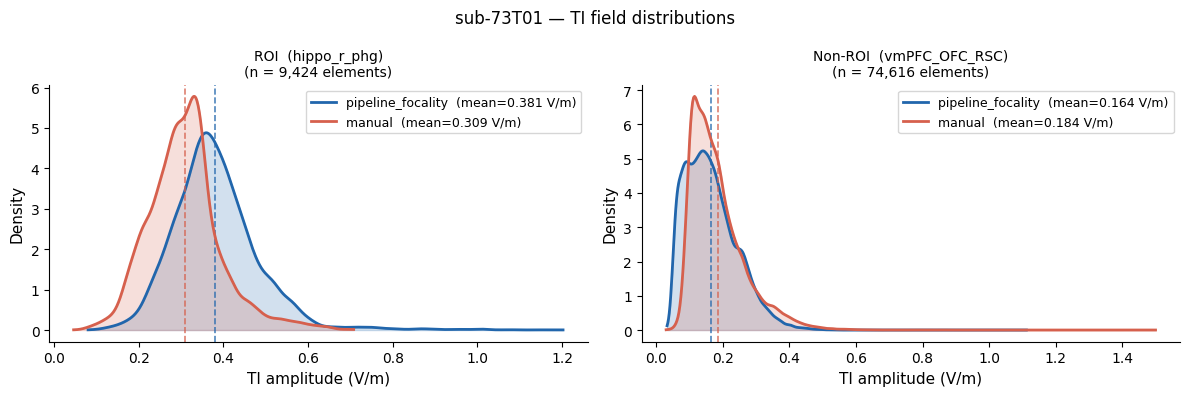


                                        pipeline       manual
------------------------------------------------------------
  ROI mean (V/m)                          0.3811       0.3088
  ROI median (V/m)                        0.3711       0.3062
  ROI p95 (V/m)                           0.5514       0.4618
  Non-ROI mean (V/m)                      0.1642       0.1838
  Non-ROI median (V/m)                    0.1532       0.1651
  Non-ROI p95 (V/m)                       0.3052       0.3473


In [11]:
# ── Cell 5: TI amplitude distributions — ROI and non-ROI ─────────────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

r = resources
ti_a = res_a['ti']
ti_b = res_b['ti']

regions = {
    'ROI  (hippo_r_phg)':       r.roi_elm_mask,
    'Non-ROI  (vmPFC_OFC_RSC)': r.non_roi_elm_mask,
}
setups = [
    (f'pipeline_{GOAL}', ti_a, '#2166ac'),
    (SETUP_B['label'],   ti_b, '#d6604d'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (region_label, mask) in zip(axes, regions.items()):
    for label, ti, color in setups:
        vals = ti[mask]
        x    = np.linspace(vals.min(), vals.max(), 500)
        kde  = gaussian_kde(vals, bw_method='scott')
        ax.fill_between(x, kde(x), alpha=0.20, color=color)
        ax.plot(x, kde(x), color=color, lw=2,
                label=f'{label}  (mean={vals.mean():.3f} V/m)')
        ax.axvline(vals.mean(), color=color, lw=1.2, ls='--', alpha=0.8)

    ax.set_xlabel('TI amplitude (V/m)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{region_label}\n(n = {mask.sum():,} elements)', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'sub-{SUBJECT} — TI field distributions', fontsize=12)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"":35s} {"pipeline":>12} {"manual":>12}')
print('-' * 60)
for region_label, mask in regions.items():
    for stat_label, fn in [
        ('mean (V/m)',  lambda x: np.mean(x)),
        ('median (V/m)',lambda x: np.median(x)),
        ('p95 (V/m)',   lambda x: np.percentile(x, 95)),
    ]:
        va = fn(ti_a[mask])
        vb = fn(ti_b[mask])
        key = f'{region_label.split("(")[0].strip()} {stat_label}'
        print(f'  {key:<33} {va:>12.4f} {vb:>12.4f}')

C:\Users\karim\AppData\Local\Temp\ipykernel_32172\2345544216.py:84: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\karim\SimNIBS-4.6\simnibs_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


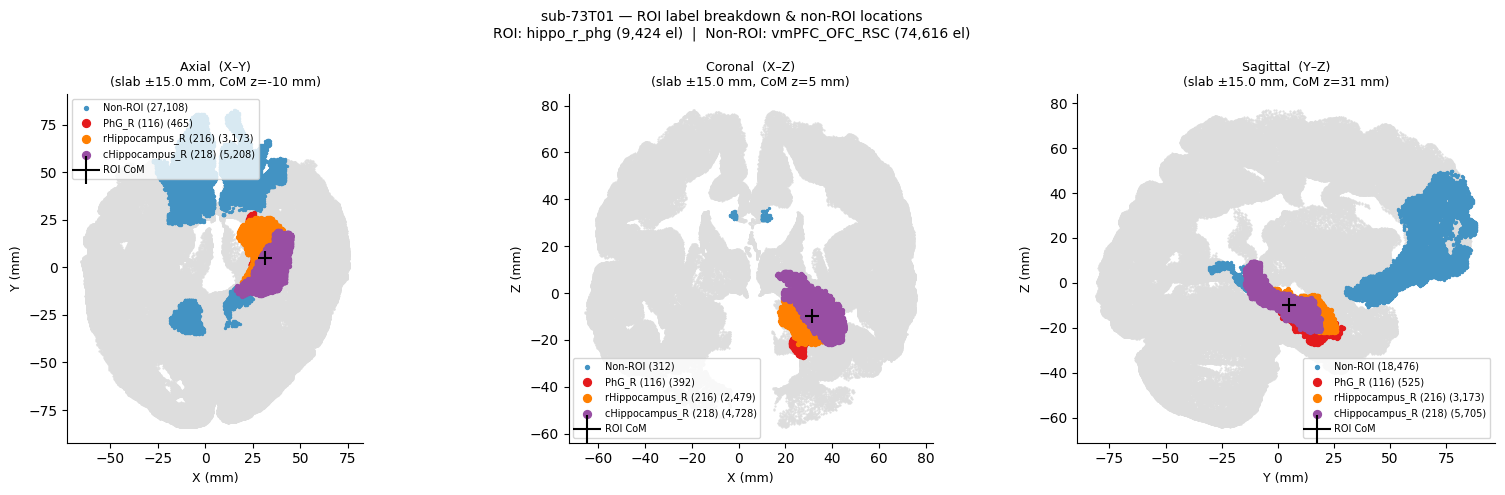

ROI CoM (subject space): X=31.4  Y=5.2  Z=-9.7 mm

  PhG_R (116):  n=525
    X: [22.3, 29.0]  Y: [0.4, 28.8]  Z: [-27.2, -9.8]
  rHippocampus_R (216):  n=3,173
    X: [17.4, 41.1]  Y: [-8.9, 26.0]  Z: [-21.7, 0.2]
  cHippocampus_R (218):  n=5,726
    X: [15.0, 45.1]  Y: [-14.8, 19.2]  Z: [-21.7, 9.3]


In [12]:
# ── Cell 5.1: ROI / non-ROI spatial validation — per-BNA-label breakdown ──────
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

r = resources
c = r.centroids      # (M, 3) mm — tissue elements only
gm = r.tags == 2

# ── Map BNA atlas labels to each element centroid ─────────────────────────────
BNA_ATLAS_SUBJ = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                               f'sub-{SUBJECT}', 'roi',
                               f'sub-{SUBJECT}_BNA_atlas_subjectspace.nii.gz')

atlas_img  = nib.load(BNA_ATLAS_SUBJ)
atlas_data = np.asarray(atlas_img.dataobj, dtype=np.int32)
aff_inv    = np.linalg.inv(atlas_img.affine)

ones    = np.ones((len(c), 1))
vox     = (aff_inv @ np.hstack([c, ones]).T).T[:, :3]
vox_idx = np.round(vox).astype(int)
sh      = atlas_data.shape
in_bounds = ((vox_idx[:, 0] >= 0) & (vox_idx[:, 0] < sh[0]) &
             (vox_idx[:, 1] >= 0) & (vox_idx[:, 1] < sh[1]) &
             (vox_idx[:, 2] >= 0) & (vox_idx[:, 2] < sh[2]))
elm_labels = np.zeros(len(c), dtype=np.int32)
elm_labels[in_bounds] = atlas_data[vox_idx[in_bounds, 0],
                                    vox_idx[in_bounds, 1],
                                    vox_idx[in_bounds, 2]]

# ── ROI label definitions ──────────────────────────────────────────────────────
ROI_LABELS = {
    'PhG_R (116)':          (116, '#e41a1c'),   # red
    'rHippocampus_R (216)': (216, '#ff7f00'),   # orange
    'cHippocampus_R (218)': (218, '#984ea3'),   # purple
}
NON_ROI_COLOR = '#4393c3'
SLAB = 15.0   # ± mm around the slice plane

roi_com = c[r.roi_elm_mask].mean(axis=0)

views = [
    ('Axial  (X–Y)',    0, 1, 2, 'X (mm)', 'Y (mm)'),
    ('Coronal  (X–Z)',  0, 2, 1, 'X (mm)', 'Z (mm)'),
    ('Sagittal  (Y–Z)', 1, 2, 0, 'Y (mm)', 'Z (mm)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, xi, yi, zi, xl, yl) in zip(axes, views):
    slab = np.abs(c[:, zi] - roi_com[zi]) < SLAB

    # GM background
    ax.scatter(c[gm & slab, xi], c[gm & slab, yi],
               s=0.3, c='#dddddd', rasterized=True)

    # Non-ROI
    nr = r.non_roi_elm_mask & slab
    ax.scatter(c[nr, xi], c[nr, yi], s=2, c=NON_ROI_COLOR,
               label=f'Non-ROI ({nr.sum():,})', rasterized=True, zorder=3)

    # Each ROI label
    for lbl_name, (lbl_val, color) in ROI_LABELS.items():
        mask = (elm_labels == lbl_val) & slab
        ax.scatter(c[mask, xi], c[mask, yi], s=8, c=color,
                   label=f'{lbl_name} ({mask.sum():,})', rasterized=True, zorder=4)

    ax.scatter(roi_com[xi], roi_com[yi], s=100, c='black',
               marker='+', zorder=5, label='ROI CoM')

    ax.set_title(f'{title}\n(slab ±{SLAB} mm, CoM z={roi_com[zi]:.0f} mm)', fontsize=9)
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, markerscale=2)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    f'sub-{SUBJECT} — ROI label breakdown & non-ROI locations\n'
    f'ROI: hippo_r_phg ({r.roi_elm_mask.sum():,} el)  |  '
    f'Non-ROI: vmPFC_OFC_RSC ({r.non_roi_elm_mask.sum():,} el)',
    fontsize=10,
)
plt.tight_layout()
plt.show()

# ── Per-label summary ─────────────────────────────────────────────────────────
print(f'ROI CoM (subject space): X={roi_com[0]:.1f}  Y={roi_com[1]:.1f}  Z={roi_com[2]:.1f} mm')
print()
for lbl_name, (lbl_val, _) in ROI_LABELS.items():
    mask = elm_labels == lbl_val
    if mask.any():
        cc = c[mask]
        print(f'  {lbl_name}:  n={mask.sum():,}')
        print(f'    X: [{cc[:,0].min():.1f}, {cc[:,0].max():.1f}]  '
              f'Y: [{cc[:,1].min():.1f}, {cc[:,1].max():.1f}]  '
              f'Z: [{cc[:,2].min():.1f}, {cc[:,2].max():.1f}]')
    else:
        print(f'  {lbl_name}:  n=0 (no elements found)')

# ── Unmatched ROI elements ────────────────────────────────────────────────────
known_labels = set(v for v, _ in ROI_LABELS.values())
unmatched = r.roi_elm_mask & ~np.isin(elm_labels, list(known_labels))
if unmatched.any():
    unique_unmatched = np.unique(elm_labels[unmatched])
    print(f'\n  WARNING: {unmatched.sum()} ROI elements not matched to any known BNA label.')
    print(f'  Unexpected labels present: {unique_unmatched[:20]}')

### Cell 4.1 — Optional: FEM validation of leadfield approach
Runs two full TDCS FEM simulations (one per channel of Setup A) and compares
the resulting TI field against the algebraic leadfield result from Cell 4.
Expect R² > 0.99 on GM elements if the leadfield is correct.
~5–10 min to run.

In [13]:
if False:
    # ── Cell 4.1: FEM validation (optional, ~5-10 min) ───────────────────────────
    import simnibs
    from simnibs import sim_struct, mesh_io
    from simnibs.utils import TI_utils as TI

    M2M_PATH   = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                            f'sub-{SUBJECT}', f'm2m_{SUBJECT}')
    FEM_OUTDIR = os.path.join(OUTPUT_DIR, 'fem_validation')
    os.makedirs(FEM_OUTDIR, exist_ok=True)

    current_A = m['current_mA'] * 1e-3

    def _run_tdcs_channel(ch_plus, ch_minus, current_A, label, m2m_path, out_dir):
        """Run a single-channel TDCS FEM and return the output .msh path."""
        s = sim_struct.SESSION()
        s.subpath  = m2m_path
        s.pathfem  = os.path.join(out_dir, label)
        s.open_in_gmsh = False

        tdcs = s.add_tdcslist()
        tdcs.currents = [current_A, -current_A]

        for ch_nr, name in enumerate([ch_plus, ch_minus], start=1):
            el = tdcs.add_electrode()
            el.channelnr  = ch_nr
            el.centre     = name          # resolved from m2m eeg_positions
            el.shape      = 'ellipse'
            el.dimensions = [14.0, 14.0]
            el.thickness  = [4.0, 1.0]   # rubber + gel

        simnibs.run_simnibs(s)

        # SimNIBS names the output after the subject id
        msh_files = sorted(glob.glob(os.path.join(s.pathfem, '*.msh')))
        if not msh_files:
            raise FileNotFoundError(f'FEM output mesh not found in {s.pathfem}')
        return msh_files[0]

    print('Running FEM channel 1...')
    msh_ch1 = _run_tdcs_channel(m['ch1_plus'], m['ch1_minus'], current_A,
                                'ch1', M2M_PATH, FEM_OUTDIR)
    print('Running FEM channel 2...')
    msh_ch2 = _run_tdcs_channel(m['ch2_plus'], m['ch2_minus'], current_A,
                                'ch2', M2M_PATH, FEM_OUTDIR)

    # ── Extract E-field vectors on tissue elements ────────────────────────────────
    def _extract_efield(msh_path, tissue_tags=[1,2,3,4,5]):
        mesh = mesh_io.read_msh(msh_path)
        m_t  = mesh.crop_mesh(tags=tissue_tags)
        # SimNIBS stores E as ElementData named 'E'
        ef_data = next(d for d in m_t.elmdata if d.field_name == 'E')
        return ef_data.value  # (N, 3)

    ef1_fem = _extract_efield(msh_ch1)
    ef2_fem = _extract_efield(msh_ch2)
    ti_fem  = TI.get_maxTI(ef1_fem, ef2_fem)

    # ── Compare against leadfield TI ──────────────────────────────────────────────
    import matplotlib.pyplot as plt
    import numpy as np

    ti_lf = res_a['ti']   # from Cell 4

    # R² on GM elements only (tag 2)
    gm_mask = resources.tags == 2
    r2 = np.corrcoef(ti_lf[gm_mask], ti_fem[gm_mask])[0, 1] ** 2
    mae = np.abs(ti_lf[gm_mask] - ti_fem[gm_mask]).mean()

    print(f'\nFEM vs Leadfield validation (GM elements, n={gm_mask.sum()})')
    print(f'  R²  : {r2:.5f}')
    print(f'  MAE : {mae*1000:.3f} mV/m')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Scatter
    axes[0].scatter(ti_lf[gm_mask], ti_fem[gm_mask], s=1, alpha=0.3, color='steelblue')
    lims = [0, max(ti_lf[gm_mask].max(), ti_fem[gm_mask].max())]
    axes[0].plot(lims, lims, 'r--', lw=1, label='y=x')
    axes[0].set_xlabel('Leadfield TI  (V/m)')
    axes[0].set_ylabel('FEM TI  (V/m)')
    axes[0].set_title(f'R² = {r2:.5f}')
    axes[0].legend()

    # Difference histogram
    diff = ti_fem[gm_mask] - ti_lf[gm_mask]
    axes[1].hist(diff * 1000, bins=80, color='steelblue', edgecolor='none')
    axes[1].axvline(0, color='r', lw=1)
    axes[1].set_xlabel('TI difference: FEM − Leadfield  (mV/m)')
    axes[1].set_ylabel('Element count')
    axes[1].set_title(f'MAE = {mae*1000:.3f} mV/m')

    plt.suptitle(f'sub-{SUBJECT} — FEM validation of leadfield  ({m["ch1_plus"]}/{m["ch2_plus"]})',
                fontsize=11)
    plt.tight_layout()
    plt.show()

---
## Group analysis — all subjects 
## (73T01, 73T02, ..., 73T14)
For each subject:
1. Parses `Results_summary.txt` (manual montage channels + currents)
2. Loads the BioSemi32 leadfield → computes pipeline TI algebraically
3. Registers BioSemi64 electrodes via Jurak 2007 MNI → subject space, runs FEM (skipped if already done)
4. Extracts mean TI in ROI and Non-ROI for both setups

Run **Cell 6.1** to collect stats, then **Cell 6.2** to plot.

In [14]:
# ── Cell 6.1: Collect group stats ─────────────────────────────────────────────
import re, csv, pathlib
import numpy as np
import simnibs
from simnibs.utils.transformations import mni2subject_coords
from simnibs import sim_struct, mesh_io
from simnibs.utils import TI_utils as TI
import importlib, compare_ti_montages
importlib.reload(compare_ti_montages)
from compare_ti_montages import load_subject_resources, compute_ti_setup, TISSUE_TAGS
import nibabel as nib

HC_LABELS = frozenset({216, 218})
EC_LABELS = frozenset({116})
VMPC_LBL  = frozenset({13, 14, 41, 42, 47, 48, 187, 188})
OFC_LBL   = frozenset({45,46,49,50})
RSC_LBL   = frozenset({181, 182})


def _atlas_elm_labels(subject, project_dir, centroids):
    path = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                        f'sub-{subject}', 'roi',
                        f'sub-{subject}_BNA_atlas_subjectspace.nii.gz')
    img  = nib.load(path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    inv  = np.linalg.inv(img.affine)
    ones = np.ones((len(centroids), 1))
    vox  = (inv @ np.hstack([centroids, ones]).T).T[:, :3]
    vi   = np.round(vox).astype(int)
    sh   = data.shape
    ok   = ((vi[:,0]>=0)&(vi[:,0]<sh[0])&
            (vi[:,1]>=0)&(vi[:,1]<sh[1])&
            (vi[:,2]>=0)&(vi[:,2]<sh[2]))
    lbl  = np.zeros(len(centroids), dtype=np.int32)
    lbl[ok] = data[vi[ok,0], vi[ok,1], vi[ok,2]]
    return lbl

# Path to the folder that contains one sub-folder per subject with Results_summary.txt
RESULTS_DIR = r'Z:\TI\SpatialNavigation\Personalized_Modelling\WP7.3\Optimized'

# ── Load Jurak 2007 MNI positions once ────────────────────────────────────────
_jurak_csv = (pathlib.Path(simnibs.__file__).parent
              / 'resources' / 'ElectrodeCaps_MNI' / 'EEG10-10_UI_Jurak_2007.csv')
_jurak = {}
with open(_jurak_csv, newline='') as f:
    for row in csv.reader(f):
        if row and row[0] in ('Electrode', 'ReferenceElectrode'):
            _jurak[row[4].strip()] = np.array([float(row[1]), float(row[2]), float(row[3])])

# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_results_summary(path):
    """Parse channels and currents from a Results_summary.txt file."""
    txt = open(path).read()
    ch  = re.search(r'Channels:\s+(\w+)-(\w+)\s+and\s+(\w+)-(\w+)', txt)
    cu  = re.search(r'Currents:\s+([\d.]+)\s+and\s+([\d.]+)', txt)
    if not ch or not cu:
        raise ValueError(f'Cannot parse channels/currents from {path}')
    return dict(
        ch1_plus=ch.group(1), ch1_minus=ch.group(2),
        ch2_plus=ch.group(3), ch2_minus=ch.group(4),
        ch1_current_mA=float(cu.group(1)),
        ch2_current_mA=float(cu.group(2)),
        label='manual',
    )
def _vol_mean_capped(vals, vols, pct=99):
    if len(vals) == 0:
        return np.nan
    cap = float(np.percentile(vals, pct))
    v   = np.minimum(vals, cap)
    return float((v * vols).sum() / vols.sum())

def _elm_mean_capped(vals, pct=99):
    """Plain (unweighted, per-element) mean, capped at the pct percentile —
    matches what run_pipeline.py's hard constraint actually enforces
    (np.mean, no volume weighting). _vol_mean_capped kept above, unused for
    now — see note about switching the pipeline's own hard-constraint check
    to volume-weighted later."""
    if len(vals) == 0:
        return np.nan
    cap = float(np.percentile(vals, pct))
    v   = np.minimum(vals, cap)
    return float(v.mean())


def _manual_fem_ti(subject, manual_cfg, project_dir, roi_mask, non_roi_mask, fem_subdir='manual_fem'):
    """
    Register BioSemi64 electrodes for this subject, run 2-channel TDCS FEM
    (skipped if .msh files already exist), and return:
        (ti_roi_mean, ti_non_roi_mean, ti_array)
    """
    m2m_path   = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                               f'sub-{subject}', f'm2m_{subject}')
    fem_outdir = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                               f'sub-{subject}', 'comparison', fem_subdir)
    os.makedirs(fem_outdir, exist_ok=True)

    # ── TI cache check — skip all mesh loading if already computed ────────────
    ti_cache = os.path.join(fem_outdir, 'ti_field.npz')
    if os.path.isfile(ti_cache):
        try:
            ti = np.load(ti_cache)['ti_all']
            print(f'    [cache] TI loaded from {fem_subdir}/ti_field.npz')
            return None, None, ti
        except Exception as _e:
            print(f'    [cache] corrupted ({_e}), recomputing')

    # MNI → subject space → scalp snap
    el_names    = [manual_cfg['ch1_plus'], manual_cfg['ch1_minus'],
                   manual_cfg['ch2_plus'], manual_cfg['ch2_minus']]
    mni_coords  = np.array([_jurak[n] for n in el_names])
    subj_coords = mni2subject_coords(mni_coords, m2m_path)
    msh_full    = mesh_io.read_msh(os.path.join(m2m_path, f'{subject}.msh'))
    scalp_nodes = msh_full.crop_mesh(tags=[5]).nodes.node_coord
    def snap(c):
        return scalp_nodes[np.argmin(np.linalg.norm(scalp_nodes - c, axis=1))]
    coords_reg = {n: snap(c) for n, c in zip(el_names, subj_coords)}

    def _fem_ch(plus, minus, current_mA, label):
        d        = os.path.join(fem_outdir, label)
        existing = sorted(glob.glob(os.path.join(d, '*.msh')))
        if existing:
            print(f'    [skip] {label}: {os.path.basename(existing[0])}')
            return existing[0]
        s = sim_struct.SESSION()
        s.subpath = m2m_path; s.pathfem = d; s.open_in_gmsh = False
        tdcs = s.add_tdcslist()
        tdcs.currents = [current_mA * 1e-3, -current_mA * 1e-3]
        for nr, nm in enumerate([plus, minus], 1):
            el = tdcs.add_electrode(); el.channelnr = nr
            el.centre     = coords_reg[nm].tolist()
            el.shape      = 'ellipse'
            # el.thickness  = [4., 1.] # OLD
            # el.dimensions = [14., 14.] # OLD
            el.dimensions = [19.5, 19.5]
            el.thickness  = [1.]
        simnibs.run_simnibs(s)
        files = sorted(glob.glob(os.path.join(d, '*.msh')))
        if not files:
            raise FileNotFoundError(f'FEM output not found in {d}')
        return files[0]

    def _ef(p):
        mt = mesh_io.read_msh(p).crop_mesh(tags=TISSUE_TAGS)
        return next(d for d in mt.elmdata if d.field_name == 'E').value

    msh1 = _fem_ch(manual_cfg['ch1_plus'],  manual_cfg['ch1_minus'],
                   manual_cfg['ch1_current_mA'], 'ch1')
    msh2 = _fem_ch(manual_cfg['ch2_plus'],  manual_cfg['ch2_minus'],
                   manual_cfg['ch2_current_mA'], 'ch2')
    ti_cache = os.path.join(fem_outdir, 'ti_field.npz')
    ti = TI.get_maxTI(_ef(msh1), _ef(msh2))
    np.savez_compressed(ti_cache, ti_all=ti)
    return None, None, ti

# ── Main loop ─────────────────────────────────────────────────────────────────
group_stats = []

for subject in ALL_SUBJECTS:
# for subject in ["73T05"]:
    print(f'\n{"="*55}')
    print(f'  sub-{subject}')
    print(f'{"="*55}')
    try:
        roi_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
            f'sub-{subject}', 'roi', f'sub-{subject}_label-hippo_r_phg_mask.nii.gz')
        nr_path  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
            f'sub-{subject}', 'roi', f'sub-{subject}_label-vmPFC_OFC_RSC_mask.nii.gz')

        # res = load_subject_resources(subject, PROJECT_DIR, 'BioSemi32_MNE', roi_path, nr_path)
        lf_path = (f"{PROJECT_DIR}/derivatives/SimNIBS/sub-{subject}/leadfield_volume"
           f"/EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm"
           f"/{subject}_leadfield_EEG10-10_UI_Jurak_2007.hdf5")
        res = load_subject_resources(subject, PROJECT_DIR, 'EEG10-10_UI_Jurak_2007',
                                   roi_path, nr_path, leadfield_path=lf_path)

        elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, res.centroids)
        hc_mask = np.isin(elm_lbl, list(HC_LABELS))
        ec_mask = np.isin(elm_lbl, list(EC_LABELS))

        vmpc_mask = np.isin(elm_lbl, list(VMPC_LBL))
        ofc_mask  = np.isin(elm_lbl, list(OFC_LBL))
        rsc_mask  = np.isin(elm_lbl, list(RSC_LBL))


        # ── Pipeline (leadfield, instant) ─────────────────────────────────────
        pl_result, pl_path = load_pipeline_result(subject, GOAL, PROJECT_DIR)
        pm = pl_result['best_montage']
        print(f'  Pipeline: {pm["ch1_plus"]}+/{pm["ch1_minus"]}-  '
              f'{pm["ch2_plus"]}+/{pm["ch2_minus"]}-  @ {pm["current_mA"]} mA')
        out_dir = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                               f'sub-{subject}', 'comparison')
        res_a = compute_ti_setup(res,
            ch1_plus=pm['ch1_plus'], ch1_minus=pm['ch1_minus'],
            ch1_current_mA=pm['current_mA'],
            ch2_plus=pm['ch2_plus'], ch2_minus=pm['ch2_minus'],
            ch2_current_mA=pm['current_mA'],
            label=f'pipeline_{GOAL}', output_dir=out_dir)
        ti_pl   = res_a['ti']
        pl_roi  = res_a['stats']['TI_mean_ROI_V_m']
        pl_nr   = res_a['stats']['TI_mean_non_ROI_V_m']
        # NOTE: volume-weighted mean — will differ from TI_mean_ROI_V_m in cached
        # JSON summary files (ti_stats_*.json), which used arithmetic mean.
        # Re-run compare_ti_montages.py per subject to refresh those files.
        
        # pl_hc = _vol_mean_capped(ti_pl[hc_mask], res.elm_volumes[hc_mask]) if hc_mask.any() else np.nan
        # pl_ec = _vol_mean_capped(ti_pl[ec_mask], res.elm_volumes[ec_mask]) if ec_mask.any() else np.nan
        
        # pl_vmpc = _vol_mean_capped(ti_pl[vmpc_mask], res.elm_volumes[vmpc_mask]) if vmpc_mask.any() else np.nan
        # pl_ofc  = _vol_mean_capped(ti_pl[ofc_mask],  res.elm_volumes[ofc_mask])  if ofc_mask.any()  else np.nan
        # pl_rsc  = _vol_mean_capped(ti_pl[rsc_mask],  res.elm_volumes[rsc_mask])  if rsc_mask.any()  else np.nan
        pl_hc = _elm_mean_capped(ti_pl[hc_mask]) if hc_mask.any() else np.nan
        pl_ec = _elm_mean_capped(ti_pl[ec_mask]) if ec_mask.any() else np.nan
        
        pl_vmpc = _elm_mean_capped(ti_pl[vmpc_mask]) if vmpc_mask.any() else np.nan
        pl_ofc  = _elm_mean_capped(ti_pl[ofc_mask])  if ofc_mask.any()  else np.nan
        pl_rsc  = _elm_mean_capped(ti_pl[rsc_mask])  if rsc_mask.any()  else np.nan

        del ti_pl

        print(f'    ROI={pl_roi:.4f}  Non-ROI={pl_nr:.4f} V/m')

        # ── Manual (leadfield-first, FEM fallback) ─────────────────────────────
        summary_txt = os.path.join(RESULTS_DIR, subject, 'Results_summary.txt')
        manual_cfg  = parse_results_summary(summary_txt)
        print(f'  Manual:   {manual_cfg["ch1_plus"]}-{manual_cfg["ch1_minus"]} '
              f'@ {manual_cfg["ch1_current_mA"]} mA  |  '
              f'{manual_cfg["ch2_plus"]}-{manual_cfg["ch2_minus"]} '
              f'@ {manual_cfg["ch2_current_mA"]} mA')
        _mn_names = [manual_cfg['ch1_plus'], manual_cfg['ch1_minus'],
                     manual_cfg['ch2_plus'], manual_cfg['ch2_minus']]
        if all(n in res.idx_lf for n in _mn_names):
            _res_b = compute_ti_setup(res,
                ch1_plus=manual_cfg['ch1_plus'], ch1_minus=manual_cfg['ch1_minus'],
                ch1_current_mA=manual_cfg['ch1_current_mA'],
                ch2_plus=manual_cfg['ch2_plus'], ch2_minus=manual_cfg['ch2_minus'],
                ch2_current_mA=manual_cfg['ch2_current_mA'],
                label=f'manual_{GOAL}', output_dir=out_dir)
            ti_mn = _res_b['ti']
            m_roi = _res_b['stats']['TI_mean_ROI_V_m']
            m_nr  = _res_b['stats'].get('TI_mean_non_ROI_V_m', np.nan)
        else:
            print('  [FEM fallback] manual electrode names not in Jurak leadfield')
            _, _, ti_mn = _manual_fem_ti(subject, manual_cfg, PROJECT_DIR,
                                          res.roi_elm_mask, res.non_roi_elm_mask)
            # m_roi = _vol_mean_capped(ti_mn[res.roi_elm_mask], res.elm_volumes[res.roi_elm_mask]) if res.roi_elm_mask.any() else np.nan
            # m_nr  = _vol_mean_capped(ti_mn[res.non_roi_elm_mask], res.elm_volumes[res.non_roi_elm_mask]) if res.non_roi_elm_mask.any() else np.nan
            m_roi = _elm_mean_capped(ti_mn[res.roi_elm_mask]) if res.roi_elm_mask.any() else np.nan
            m_nr  = _elm_mean_capped(ti_mn[res.non_roi_elm_mask]) if res.non_roi_elm_mask.any() else np.nan

        # m_hc   = _vol_mean_capped(ti_mn[hc_mask],   res.elm_volumes[hc_mask])   if hc_mask.any()   else np.nan
        # m_ec   = _vol_mean_capped(ti_mn[ec_mask],   res.elm_volumes[ec_mask])   if ec_mask.any()   else np.nan
        # m_vmpc = _vol_mean_capped(ti_mn[vmpc_mask], res.elm_volumes[vmpc_mask]) if vmpc_mask.any() else np.nan
        # m_ofc  = _vol_mean_capped(ti_mn[ofc_mask],  res.elm_volumes[ofc_mask])  if ofc_mask.any()  else np.nan
        # m_rsc  = _vol_mean_capped(ti_mn[rsc_mask],  res.elm_volumes[rsc_mask])  if rsc_mask.any()  else np.nan

        m_hc   = _elm_mean_capped(ti_mn[hc_mask])   if hc_mask.any()   else np.nan
        m_ec   = _elm_mean_capped(ti_mn[ec_mask])   if ec_mask.any()   else np.nan
        m_vmpc = _elm_mean_capped(ti_mn[vmpc_mask]) if vmpc_mask.any() else np.nan
        m_ofc  = _elm_mean_capped(ti_mn[ofc_mask])  if ofc_mask.any()  else np.nan
        m_rsc  = _elm_mean_capped(ti_mn[rsc_mask])  if rsc_mask.any()  else np.nan
        del ti_mn


        print(f'    ROI={m_roi:.4f}  Non-ROI={m_nr:.4f} V/m')

        # ── Template (leadfield-first, FEM fallback) ──────────────────────────
        print(f'  Template: {SETUP_C["ch1_plus"]}-{SETUP_C["ch1_minus"]} '
              f'@ {SETUP_C["ch1_current_mA"]} mA  |  '
              f'{SETUP_C["ch2_plus"]}-{SETUP_C["ch2_minus"]} '
              f'@ {SETUP_C["ch2_current_mA"]} mA')
        _tc_names = [SETUP_C['ch1_plus'], SETUP_C['ch1_minus'],
                     SETUP_C['ch2_plus'], SETUP_C['ch2_minus']]
        if all(n in res.idx_lf for n in _tc_names):
            _res_c = compute_ti_setup(res,
                ch1_plus=SETUP_C['ch1_plus'], ch1_minus=SETUP_C['ch1_minus'],
                ch1_current_mA=SETUP_C['ch1_current_mA'],
                ch2_plus=SETUP_C['ch2_plus'], ch2_minus=SETUP_C['ch2_minus'],
                ch2_current_mA=SETUP_C['ch2_current_mA'],
                label=f'template_{GOAL}', output_dir=out_dir)
            ti_tm = _res_c['ti']
            t_roi = _res_c['stats']['TI_mean_ROI_V_m']
            t_nr  = _res_c['stats'].get('TI_mean_non_ROI_V_m', np.nan)
        else:
            print('  [FEM fallback] template electrode names not in Jurak leadfield')
            _, _, ti_tm = _manual_fem_ti(subject, SETUP_C, PROJECT_DIR,
                                          res.roi_elm_mask, res.non_roi_elm_mask,
                                          fem_subdir='template_fem')
        #     t_roi = _vol_mean_capped(ti_tm[res.roi_elm_mask], res.elm_volumes[res.roi_elm_mask]) if res.roi_elm_mask.any() else np.nan
        #     t_nr  = _vol_mean_capped(ti_tm[res.non_roi_elm_mask], res.elm_volumes[res.non_roi_elm_mask]) if res.non_roi_elm_mask.any() else np.nan
        # t_hc   = _vol_mean_capped(ti_tm[hc_mask],   res.elm_volumes[hc_mask])   if hc_mask.any()   else np.nan
        # t_ec   = _vol_mean_capped(ti_tm[ec_mask],   res.elm_volumes[ec_mask])   if ec_mask.any()   else np.nan
        # t_vmpc = _vol_mean_capped(ti_tm[vmpc_mask], res.elm_volumes[vmpc_mask]) if vmpc_mask.any() else np.nan
        # t_ofc  = _vol_mean_capped(ti_tm[ofc_mask],  res.elm_volumes[ofc_mask])  if ofc_mask.any()  else np.nan
        # t_rsc  = _vol_mean_capped(ti_tm[rsc_mask],  res.elm_volumes[rsc_mask])  if rsc_mask.any()  else np.nan

            t_roi = _elm_mean_capped(ti_tm[res.roi_elm_mask]) if res.roi_elm_mask.any() else np.nan
            t_nr  = _elm_mean_capped(ti_tm[res.non_roi_elm_mask]) if res.non_roi_elm_mask.any() else np.nan
        t_hc   = _elm_mean_capped(ti_tm[hc_mask])   if hc_mask.any()   else np.nan
        t_ec   = _elm_mean_capped(ti_tm[ec_mask])   if ec_mask.any()   else np.nan
        t_vmpc = _elm_mean_capped(ti_tm[vmpc_mask]) if vmpc_mask.any() else np.nan
        t_ofc  = _elm_mean_capped(ti_tm[ofc_mask])  if ofc_mask.any()  else np.nan
        t_rsc  = _elm_mean_capped(ti_tm[rsc_mask])  if rsc_mask.any()  else np.nan

        del ti_tm

        del res
        
        import gc; gc.collect()

        print(f'    ROI={t_roi:.4f}  Non-ROI={t_nr:.4f} V/m')

        group_stats.append(dict(
            subject               = subject,
            pipeline_roi_mean     = pl_roi,
            pipeline_non_roi_mean = pl_nr,
            manual_roi_mean       = m_roi,
            manual_non_roi_mean   = m_nr,
            manual_ch1            = f'{manual_cfg["ch1_plus"]}-{manual_cfg["ch1_minus"]}',
            manual_ch2            = f'{manual_cfg["ch2_plus"]}-{manual_cfg["ch2_minus"]}',
            pipeline_ch1          = f'{pm["ch1_plus"]}-{pm["ch1_minus"]}',
            pipeline_ch2          = f'{pm["ch2_plus"]}-{pm["ch2_minus"]}',
            template_roi_mean     = t_roi,
            template_non_roi_mean = t_nr,
            template_ch1          = f'{SETUP_C["ch1_plus"]}-{SETUP_C["ch1_minus"]}',
            template_ch2          = f'{SETUP_C["ch2_plus"]}-{SETUP_C["ch2_minus"]}',
            # sub-ROIs
            hc_pipeline_mean   = pl_hc,
            hc_manual_mean     = m_hc,
            hc_template_mean   = t_hc,
            ec_pipeline_mean   = pl_ec,
            ec_manual_mean     = m_ec,
            ec_template_mean   = t_ec,
            # sub-nonROIs
            vmpc_pipeline_mean = pl_vmpc,
            vmpc_manual_mean   = m_vmpc,
            vmpc_template_mean = t_vmpc,
            ofc_pipeline_mean  = pl_ofc,
            ofc_manual_mean    = m_ofc,
            ofc_template_mean  = t_ofc,
            rsc_pipeline_mean  = pl_rsc,
            rsc_manual_mean    = m_rsc,
            rsc_template_mean  = t_rsc,
            #
            pipeline_current_mA     = pm['current_mA'],
            manual_ch1_current_mA   = manual_cfg['ch1_current_mA'],
            manual_ch2_current_mA   = manual_cfg['ch2_current_mA'],
            template_ch1_current_mA = SETUP_C['ch1_current_mA'],
            template_ch2_current_mA = SETUP_C['ch2_current_mA'],


        ))

    except Exception as exc:
        print(f'  ERROR: {exc}')
        import traceback; traceback.print_exc()

print(f'\n{"="*55}')
print(f'Completed {len(group_stats)} / {len(ALL_SUBJECTS)} subjects')
print(f'{"="*55}')


  sub-73T01
Loading leadfield: D:/MINDS_Project_Karim/BIDS_TI_Toolbox/derivatives/SimNIBS/sub-73T01/leadfield_volume/EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm/73T01_leadfield_EEG10-10_UI_Jurak_2007.hdf5
  Leadfield shape: (75, 3062164, 3)  (76 electrodes)
  ROI elements    : 9424
  Non-ROI elements: 74616
  Pipeline: T9+/C6-  TP8+/I1-  @ 2.0 mA
  [cache] pipeline_focality — loading pre-computed TI field
    ROI=0.3805  Non-ROI=0.1558 V/m
  Manual:   F8-FC3 @ 1.9245 mA  |  P5-TP10 @ 1.9994 mA
  [cache] manual_focality — loading pre-computed TI field
    ROI=0.3083  Non-ROI=0.1794 V/m
  Template: FT7-Fp2 @ 1.9245 mA  |  TP7-P8 @ 1.9994 mA
  [cache] template_focality — loading pre-computed TI field
    ROI=0.2215  Non-ROI=0.1765 V/m

  sub-73T02
Loading leadfield: D:/MINDS_Project_Karim/BIDS_TI_Toolbox/derivatives/SimNIBS/sub-73T02/leadfield_volume/EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm/73T02_leadfield_EEG10-10_UI_Jurak_2007.hdf5
  Leadfield shape: (75, 2841804, 3)  (76 electr

In [15]:
# ── Export results to CSV ──────────────────────────────────────────────────────
import csv, os
import numpy as np

OUT_DIR = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS')

METRICS = [
    ('ROI_joined_V_m',       'pipeline_roi_mean',    'manual_roi_mean',    'template_roi_mean'),
    ('HC_V_m',               'hc_pipeline_mean',     'hc_manual_mean',     'hc_template_mean'),
    ('EntorhinalCtx_R_V_m',  'ec_pipeline_mean',     'ec_manual_mean',     'ec_template_mean'),
    ('nonROI_joined_V_m',    'pipeline_non_roi_mean','manual_non_roi_mean','template_non_roi_mean'),
    ('vmPFC_V_m',            'vmpc_pipeline_mean',   'vmpc_manual_mean',   'vmpc_template_mean'),
    ('OFC_V_m',              'ofc_pipeline_mean',    'ofc_manual_mean',    'ofc_template_mean'),
    ('RSC_V_m',              'rsc_pipeline_mean',    'rsc_manual_mean',    'rsc_template_mean'),
]

def _fmt(v):
    return f'{v:.4f}' if isinstance(v, float) and not np.isnan(v) else ('' if isinstance(v, float) else str(v))

def _split_ch(ch_str):
    parts = ch_str.split('-')
    return parts[0], parts[1] if len(parts) > 1 else ('', '')

# ── Per-subject CSVs ──────────────────────────────────────────────────────────
for s in group_stats:
    path = os.path.join(OUT_DIR, f'sub-{s["subject"]}_TI_results.csv')
    pl1p, pl1m = _split_ch(s['pipeline_ch1'])
    pl2p, pl2m = _split_ch(s['pipeline_ch2'])
    mn1p, mn1m = _split_ch(s['manual_ch1'])
    mn2p, mn2m = _split_ch(s['manual_ch2'])
    tm1p, tm1m = _split_ch(s['template_ch1'])
    tm2p, tm2m = _split_ch(s['template_ch2'])
    with open(path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['Metric', 'Pipeline', 'Manual', 'Template'])
        for label, pk, mk, tk in METRICS:
            w.writerow([label, _fmt(s[pk]), _fmt(s[mk]), _fmt(s[tk])])
        w.writerow(['Ch1_plus',         pl1p, mn1p, tm1p])
        w.writerow(['Ch1_minus',        pl1m, mn1m, tm1m])
        w.writerow(['Ch1_current_mA',   _fmt(s['pipeline_current_mA']),
                                        _fmt(s['manual_ch1_current_mA']),
                                        _fmt(s['template_ch1_current_mA'])])
        w.writerow(['Ch2_plus',         pl2p, mn2p, tm2p])
        w.writerow(['Ch2_minus',        pl2m, mn2m, tm2m])
        w.writerow(['Ch2_current_mA',   _fmt(s['pipeline_current_mA']),
                                        _fmt(s['manual_ch2_current_mA']),
                                        _fmt(s['template_ch2_current_mA'])])
    print(f'  Saved → {path}')

# ── Group CSV ─────────────────────────────────────────────────────────────────
group_path = os.path.join(OUT_DIR, 'group_TI_results.csv')

header = ['Subject']
for label, pk, mk, tk in METRICS:
    m = label.replace('_V_m', '')
    header += [f'PL_{m}', f'MN_{m}', f'TM_{m}']
header += [
    'PL_Ch1_plus','PL_Ch1_minus','PL_Ch1_current_mA',
    'PL_Ch2_plus','PL_Ch2_minus','PL_Ch2_current_mA',
    'MN_Ch1_plus','MN_Ch1_minus','MN_Ch1_current_mA',
    'MN_Ch2_plus','MN_Ch2_minus','MN_Ch2_current_mA',
    'TM_Ch1_plus','TM_Ch1_minus','TM_Ch1_current_mA',
    'TM_Ch2_plus','TM_Ch2_minus','TM_Ch2_current_mA',
]

rows = []
for s in group_stats:
    pl1p, pl1m = _split_ch(s['pipeline_ch1'])
    pl2p, pl2m = _split_ch(s['pipeline_ch2'])
    mn1p, mn1m = _split_ch(s['manual_ch1'])
    mn2p, mn2m = _split_ch(s['manual_ch2'])
    tm1p, tm1m = _split_ch(s['template_ch1'])
    tm2p, tm2m = _split_ch(s['template_ch2'])
    row = [s['subject']]
    for label, pk, mk, tk in METRICS:
        row += [_fmt(s[pk]), _fmt(s[mk]), _fmt(s[tk])]
    row += [
        pl1p, pl1m, _fmt(s['pipeline_current_mA']),
        pl2p, pl2m, _fmt(s['pipeline_current_mA']),
        mn1p, mn1m, _fmt(s['manual_ch1_current_mA']),
        mn2p, mn2m, _fmt(s['manual_ch2_current_mA']),
        tm1p, tm1m, _fmt(s['template_ch1_current_mA']),
        tm2p, tm2m, _fmt(s['template_ch2_current_mA']),
    ]
    rows.append(row)

for stat_label, fn in [('Mean', np.nanmean), ('SD', np.nanstd)]:
    row = [stat_label]
    for label, pk, mk, tk in METRICS:
        for key in [pk, mk, tk]:
            vals = [s[key] for s in group_stats if isinstance(s[key], float) and not np.isnan(s[key])]
            row.append(_fmt(fn(vals)) if vals else '')
    row += [''] * 18
    rows.append(row)

with open(group_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(header)
    w.writerows(rows)

print(f'  Saved → {group_path}')
print(f'\nAll CSVs written to: {OUT_DIR}')


  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T01_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T02_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T03_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T04_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T05_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T06_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T07_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T09_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T10_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\sub-73T11_TI_results.csv
  Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives

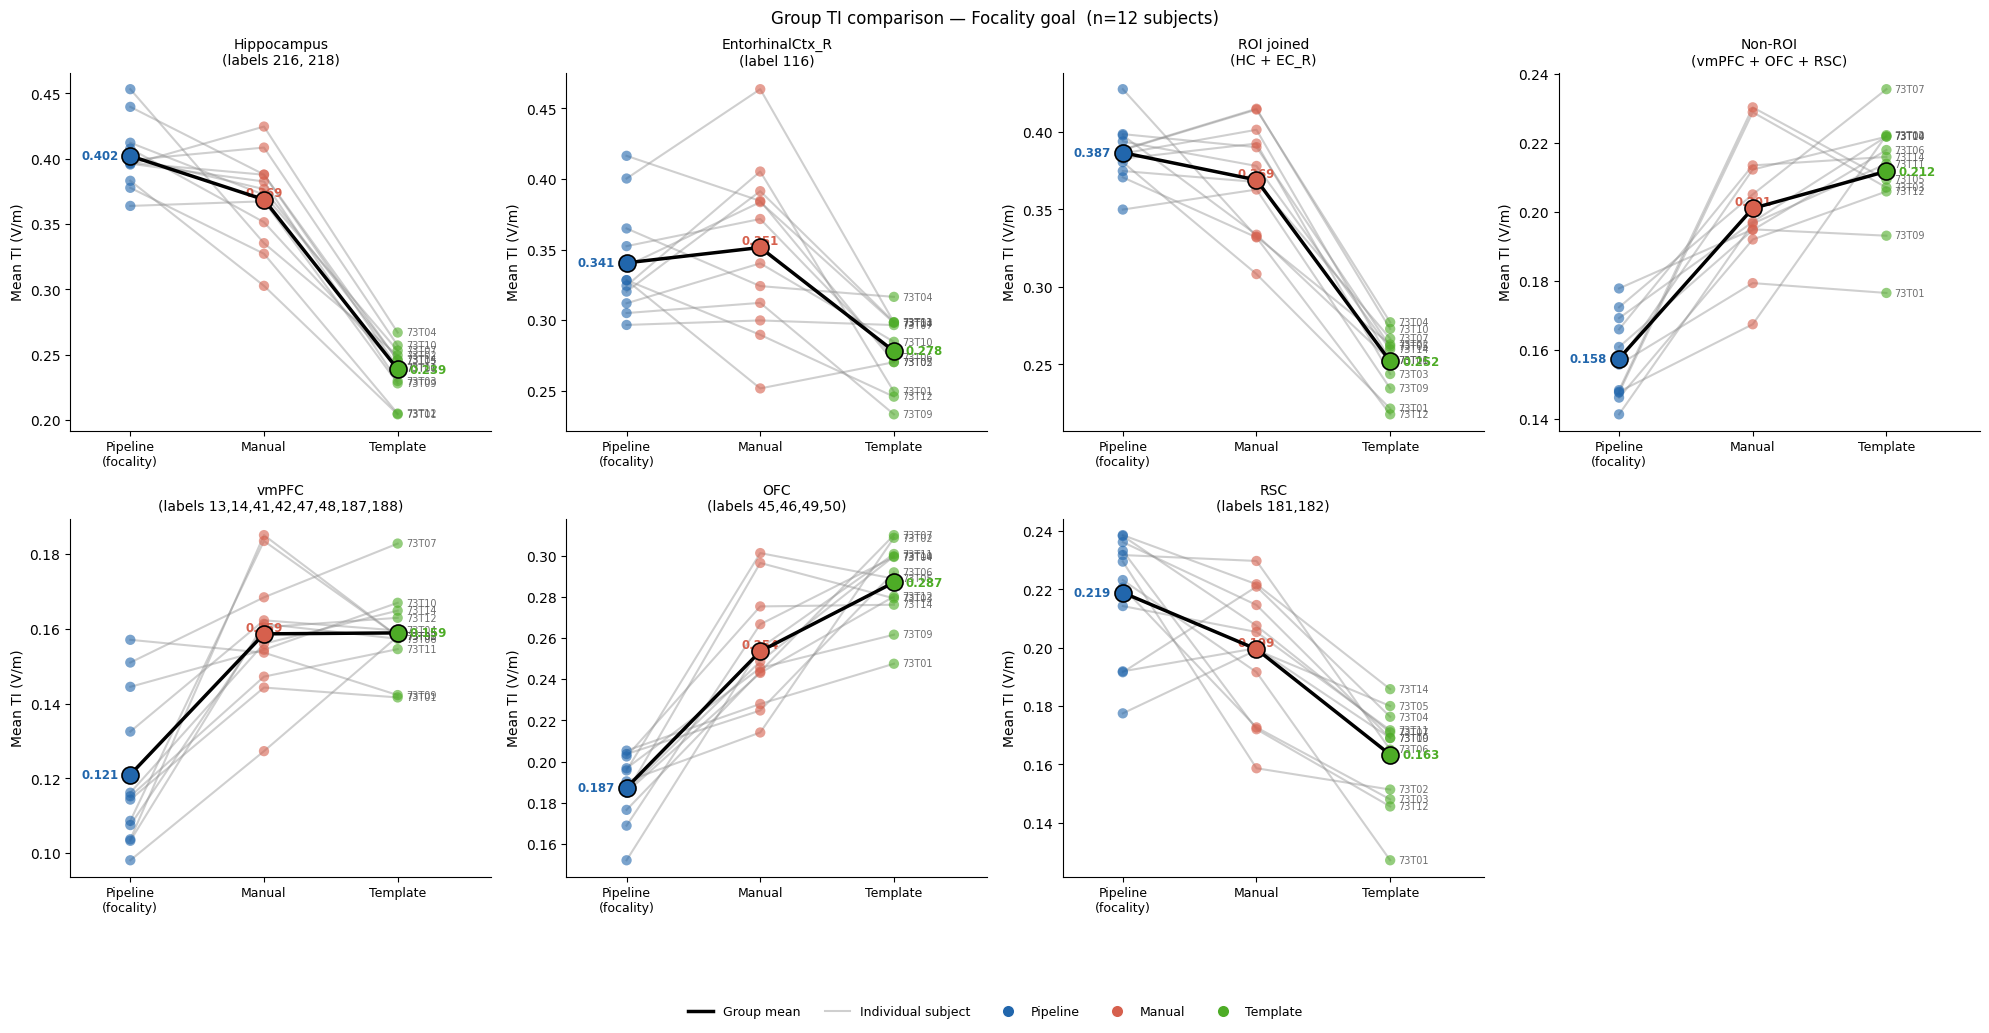

Figure saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\group_TI_comparison_focality.png

Metric                                    Pipeline              Manual            Template
------------------------------------------------------------------------------------------
  Hippocampus                    0.4022 ± 0.0236   0.3687 ± 0.0332   0.2388 ± 0.0185
  EntorhinalCtx_R                0.3406 ± 0.0354   0.3515 ± 0.0566   0.2780 ± 0.0243
  ROI joined                     0.3867 ± 0.0178   0.3691 ± 0.0341   0.2520 ± 0.0183
  Non-ROI                        0.1575 ± 0.0112   0.2010 ± 0.0176   0.2117 ± 0.0147
  vmPFC                          0.1210 ± 0.0193   0.1586 ± 0.0153   0.1589 ± 0.0103
  OFC                            0.1873 ± 0.0150   0.2535 ± 0.0260   0.2869 ± 0.0181
  RSC                            0.2189 ± 0.0200   0.1995 ± 0.0212   0.1633 ± 0.0162

Per-subject detail:
  Subj        PL-HC    MN-HC    TM-HC    PL-EC    MN-EC    TM-EC   PL-ROI   MN-ROI   TM-ROI   

In [16]:
# ── Cell 6.2: Group plot ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

if not group_stats:
    raise RuntimeError('group_stats is empty — run Cell 6.1 first.')

subjects     = [s['subject'] for s in group_stats]
COLOR_PL  = '#2166ac'
COLOR_MN  = '#d6604d'
COLOR_TM  = '#4dac26'
ALPHA_IND = 0.40
X = [0, 1, 2]

def _extract(key):
    return np.array([s[key] for s in group_stats])

panels = [
    ('Hippocampus\n(labels 216, 218)',
     _extract('hc_pipeline_mean'), _extract('hc_manual_mean'), _extract('hc_template_mean'),
     'Mean TI (V/m)'),
    ('EntorhinalCtx_R\n(label 116)',
     _extract('ec_pipeline_mean'), _extract('ec_manual_mean'), _extract('ec_template_mean'),
     'Mean TI (V/m)'),
    ('ROI joined\n(HC + EC_R)',
     _extract('pipeline_roi_mean'), _extract('manual_roi_mean'), _extract('template_roi_mean'),
     'Mean TI (V/m)'),
    ('Non-ROI\n(vmPFC + OFC + RSC)',
     _extract('pipeline_non_roi_mean'), _extract('manual_non_roi_mean'), _extract('template_non_roi_mean'),
     'Mean TI (V/m)'),
    
    ('vmPFC\n(labels 13,14,41,42,47,48,187,188)',
     _extract('vmpc_pipeline_mean'), _extract('vmpc_manual_mean'), _extract('vmpc_template_mean'),
     'Mean TI (V/m)'),
    ('OFC\n(labels 45,46,49,50)',
     _extract('ofc_pipeline_mean'), _extract('ofc_manual_mean'), _extract('ofc_template_mean'),
     'Mean TI (V/m)'),
    ('RSC\n(labels 181,182)',
     _extract('rsc_pipeline_mean'), _extract('rsc_manual_mean'), _extract('rsc_template_mean'),
     'Mean TI (V/m)'),

]

# fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

# for ax, (title, pl_vals, mn_vals, tm_vals, ylabel) in zip(axes, panels):
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)

for ax, (title, pl_vals, mn_vals, tm_vals, ylabel) in zip(axes.flat, panels):

    for pv, mv, tv, subj in zip(pl_vals, mn_vals, tm_vals, subjects):
        ax.plot(X, [pv, mv, tv], color='#888888', alpha=ALPHA_IND, lw=1.5, zorder=2)
        ax.scatter([0], [pv], color=COLOR_PL, alpha=ALPHA_IND + 0.2, s=55,
                   zorder=3, edgecolors='none')
        ax.scatter([1], [mv], color=COLOR_MN, alpha=ALPHA_IND + 0.2, s=55,
                   zorder=3, edgecolors='none')
        ax.scatter([2], [tv], color=COLOR_TM, alpha=ALPHA_IND + 0.2, s=55,
                   zorder=3, edgecolors='none')
        ax.text(2.06, tv, subj, va='center', ha='left', fontsize=7, color='#555555', alpha=0.85)

    gm_pl = np.nanmean(pl_vals)
    gm_mn = np.nanmean(mn_vals)
    gm_tm = np.nanmean(tm_vals)
    ax.plot(X, [gm_pl, gm_mn, gm_tm], color='black', lw=2.5, zorder=5)
    ax.scatter([0], [gm_pl], color=COLOR_PL, s=150, zorder=6, edgecolors='black', linewidths=1.2)
    ax.scatter([1], [gm_mn], color=COLOR_MN, s=150, zorder=6, edgecolors='black', linewidths=1.2)
    ax.scatter([2], [gm_tm], color=COLOR_TM, s=150, zorder=6, edgecolors='black', linewidths=1.2)

    ax.text(-0.09, gm_pl, f'{gm_pl:.3f}', ha='right',  va='center',
            fontsize=8.5, color=COLOR_PL, fontweight='bold')
    ax.text(1.00,  gm_mn, f'{gm_mn:.3f}', ha='center', va='bottom',
            fontsize=8.5, color=COLOR_MN, fontweight='bold')
    ax.text(2.09,  gm_tm, f'{gm_tm:.3f}', ha='left',   va='center',
            fontsize=8.5, color=COLOR_TM, fontweight='bold')

    ax.set_xticks(X)
    ax.set_xticklabels([f'Pipeline\n({GOAL})', 'Manual', 'Template'], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(-0.45, 2.70)
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

leg_handles = [
    mlines.Line2D([], [], color='black', lw=2.5, label='Group mean'),
    mlines.Line2D([], [], color='#888888', lw=1.5, alpha=ALPHA_IND, label='Individual subject'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_PL, markersize=9, label='Pipeline'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_MN, markersize=9, label='Manual'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_TM, markersize=9, label='Template'),
]
axes.flat[-1].set_visible(False)

fig.legend(handles=leg_handles, loc='lower center', ncol=5,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    f'Group TI comparison — {GOAL.capitalize()} goal  (n={len(group_stats)} subjects)',
    fontsize=12,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
out_png = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                        f'group_TI_comparison_{GOAL}.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {out_png}')

# ── Numeric summary ────────────────────────────────────────────────────────────
print(f'\n{"Metric":<30}  {"Pipeline":>18}  {"Manual":>18}  {"Template":>18}')
print('-' * 90)
for lbl, pk, mk, tk in [
    ('Hippocampus',   'hc_pipeline_mean',       'hc_manual_mean',       'hc_template_mean'),
    ('EntorhinalCtx_R', 'ec_pipeline_mean',     'ec_manual_mean',       'ec_template_mean'),
    ('ROI joined',    'pipeline_roi_mean',       'manual_roi_mean',      'template_roi_mean'),
    ('Non-ROI',       'pipeline_non_roi_mean',   'manual_non_roi_mean',  'template_non_roi_mean'),
    ('vmPFC',  'vmpc_pipeline_mean', 'vmpc_manual_mean', 'vmpc_template_mean'),
    ('OFC',    'ofc_pipeline_mean',  'ofc_manual_mean',  'ofc_template_mean'),
    ('RSC',    'rsc_pipeline_mean',  'rsc_manual_mean',  'rsc_template_mean'),

]:
    pl_v = np.array([s[pk] for s in group_stats])
    mn_v = np.array([s[mk] for s in group_stats])
    tm_v = np.array([s[tk] for s in group_stats])
    print(f'  {lbl:<28}  {np.nanmean(pl_v):>7.4f} ± {np.nanstd(pl_v):.4f}'
          f'  {np.nanmean(mn_v):>7.4f} ± {np.nanstd(mn_v):.4f}'
          f'  {np.nanmean(tm_v):>7.4f} ± {np.nanstd(tm_v):.4f}')

print(f'\nPer-subject detail:')
# print(f'  {"Subj":<8}  {"PL-HC":>7}  {"MN-HC":>7}  {"TM-HC":>7}'
#       f'  {"PL-EC":>7}  {"MN-EC":>7}  {"TM-EC":>7}'
#       f'  {"PL-ROI":>7}  {"MN-ROI":>7}  {"TM-ROI":>7}')
# print(f'  {"-"*88}')
# for s in group_stats:
#     print(f'  {s["subject"]:<8}'
#           f'  {s["hc_pipeline_mean"]:>7.4f}  {s["hc_manual_mean"]:>7.4f}  {s["hc_template_mean"]:>7.4f}'
#           f'  {s["ec_pipeline_mean"]:>7.4f}  {s["ec_manual_mean"]:>7.4f}  {s["ec_template_mean"]:>7.4f}'
#           f'  {s["pipeline_roi_mean"]:>7.4f}  {s["manual_roi_mean"]:>7.4f}  {s["template_roi_mean"]:>7.4f}')

print(f'  {"Subj":<8}  {"PL-HC":>7}  {"MN-HC":>7}  {"TM-HC":>7}'
      f'  {"PL-EC":>7}  {"MN-EC":>7}  {"TM-EC":>7}'
      f'  {"PL-ROI":>7}  {"MN-ROI":>7}  {"TM-ROI":>7}'
      f'  {"PL-vMFC":>8}  {"MN-vMFC":>8}  {"TM-vMFC":>8}'
      f'  {"PL-OFC":>7}  {"MN-OFC":>7}  {"TM-OFC":>7}'
      f'  {"PL-RSC":>7}  {"MN-RSC":>7}  {"TM-RSC":>7}')
print(f'  {"-"*140}')
for s in group_stats:
    print(f'  {s["subject"]:<8}'
          f'  {s["hc_pipeline_mean"]:>7.4f}  {s["hc_manual_mean"]:>7.4f}  {s["hc_template_mean"]:>7.4f}'
          f'  {s["ec_pipeline_mean"]:>7.4f}  {s["ec_manual_mean"]:>7.4f}  {s["ec_template_mean"]:>7.4f}'
          f'  {s["pipeline_roi_mean"]:>7.4f}  {s["manual_roi_mean"]:>7.4f}  {s["template_roi_mean"]:>7.4f}'
          f'  {s["vmpc_pipeline_mean"]:>8.4f}  {s["vmpc_manual_mean"]:>8.4f}  {s["vmpc_template_mean"]:>8.4f}'
          f'  {s["ofc_pipeline_mean"]:>7.4f}  {s["ofc_manual_mean"]:>7.4f}  {s["ofc_template_mean"]:>7.4f}'
          f'  {s["rsc_pipeline_mean"]:>7.4f}  {s["rsc_manual_mean"]:>7.4f}  {s["rsc_template_mean"]:>7.4f}')



In [17]:
# ── Cell 6.3: Subregion breakdown — compute ────────────────────────────────────
import numpy as np
import nibabel as nib
from simnibs import mesh_io
from simnibs.utils import TI_utils as TI
from compare_ti_montages import load_subject_resources, compute_ti_setup, TISSUE_TAGS

ROI_SUBGROUPS = {
    'Hippocampus':  frozenset({216, 218}),
    'EntorhinalCtx_R': frozenset({116}),
    'ROI_joined': frozenset({116, 216, 218})
}
# NON_ROI_SUBGROUPS = {
#     'vmPFC':  frozenset({13, 14, 41, 42}),
#     'OFC':    frozenset({47, 48}),
#     'RSC':    frozenset({181, 182, 187, 188}),
# }
NON_ROI_SUBGROUPS = {
    'vmPFC': {13, 14, 41, 42, 47, 48, 187, 188},
    'OFC':   {45, 46, 49, 50},
    'RSC':   {181, 182},
    'non_ROI_joined': {13, 14, 41, 42, 45, 46, 47, 48, 49, 50, 181, 182, 187, 188}
}

ALL_SUBGROUPS = {**ROI_SUBGROUPS, **NON_ROI_SUBGROUPS}

def _load_cached_ti(subject, project_dir, fem_subdir):
    """Extract TI from already-computed FEM outputs; caches result to ti_field.npz."""
    fem_dir  = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                            f'sub-{subject}', 'comparison', fem_subdir)
    ti_cache = os.path.join(fem_dir, 'ti_field.npz')
    if os.path.isfile(ti_cache):
        try:
            ti = np.load(ti_cache)['ti_all']
            print(f'    [cache] TI loaded from {fem_subdir}/ti_field.npz')
            return ti

        except Exception as _e:
            print(f'    [cache] corrupted ({_e}), recomputing')

    msh1 = sorted(glob.glob(os.path.join(fem_dir, 'ch1', '*.msh')))
    msh2 = sorted(glob.glob(os.path.join(fem_dir, 'ch2', '*.msh')))
    if not msh1 or not msh2:
        raise FileNotFoundError(
            f'{fem_subdir} FEM not found for sub-{subject}. Run Cell 6.1 first.')
    def _ef(p):
        mt = mesh_io.read_msh(p).crop_mesh(tags=TISSUE_TAGS)
        return next(d for d in mt.elmdata if d.field_name == 'E').value
    ti = TI.get_maxTI(_ef(msh1[0]), _ef(msh2[0]))
    np.savez_compressed(ti_cache, ti_all=ti)
    return ti

# # LEGACY name kept for backwards compatibility
# def _load_manual_ti(subject, project_dir):
#     return _load_cached_ti(subject, project_dir, 'manual_fem')

def _atlas_elm_labels(subject, project_dir, centroids):
    """Return integer BNA label per mesh element centroid."""
    path = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                        f'sub-{subject}', 'roi',
                        f'sub-{subject}_BNA_atlas_subjectspace.nii.gz')
    img  = nib.load(path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    inv  = np.linalg.inv(img.affine)
    ones = np.ones((len(centroids), 1))
    vox  = (inv @ np.hstack([centroids, ones]).T).T[:, :3]
    vi   = np.round(vox).astype(int)
    sh   = data.shape
    ok   = ((vi[:,0]>=0)&(vi[:,0]<sh[0])&
            (vi[:,1]>=0)&(vi[:,1]<sh[1])&
            (vi[:,2]>=0)&(vi[:,2]<sh[2]))
    lbl  = np.zeros(len(centroids), dtype=np.int32)
    lbl[ok] = data[vi[ok,0], vi[ok,1], vi[ok,2]]
    return lbl

# ── Main loop ──────────────────────────────────────────────────────────────────
subpart_data = []

# for s in group_stats:
#     subject = s['subject']
#     print(f'\n  sub-{subject}', end='', flush=True)
#     try:
#         roi_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
#             f'sub-{subject}', 'roi', f'sub-{subject}_label-hippo_r_phg_mask.nii.gz')
#         nr_path  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
#             f'sub-{subject}', 'roi', f'sub-{subject}_label-vmPFC_OFC_RSC_mask.nii.gz')
#         # res = load_subject_resources(subject, PROJECT_DIR, 'BioSemi32_MNE', roi_path, nr_path)
#         lf_path = (f"{PROJECT_DIR}/derivatives/SimNIBS/sub-{subject}/leadfield_volume"
#                 f"/EEG10-10_UI_Jurak_2007__ellipse_19.5x19.5_1mm"
#                 f"/{subject}_leadfield_EEG10-10_UI_Jurak_2007.hdf5")
#         res = load_subject_resources(subject, PROJECT_DIR, 'EEG10-10_UI_Jurak_2007',
#                                    roi_path, nr_path, leadfield_path=lf_path)

#         elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, res.centroids)

#         # Pipeline TI (leadfield)
#         pl_result, _ = load_pipeline_result(subject, GOAL, PROJECT_DIR)
#         pm = pl_result['best_montage']
#         out_dir = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
#                                f'sub-{subject}', 'comparison')
#         res_a = compute_ti_setup(res,
#             ch1_plus=pm['ch1_plus'], ch1_minus=pm['ch1_minus'],
#             ch1_current_mA=pm['current_mA'],
#             ch2_plus=pm['ch2_plus'], ch2_minus=pm['ch2_minus'],
#             ch2_current_mA=pm['current_mA'],
#             label=f'pipeline_{GOAL}', output_dir=out_dir)
#         ti_pl = res_a['ti']

#         # Manual TI (leadfield-first; cache from Cell 6.1 makes this instant)
#         manual_cfg = parse_results_summary(os.path.join(RESULTS_DIR, subject, 'Results_summary.txt'))
#         _mn_names  = [manual_cfg['ch1_plus'], manual_cfg['ch1_minus'],
#                       manual_cfg['ch2_plus'], manual_cfg['ch2_minus']]
#         if all(n in res.idx_lf for n in _mn_names):
#             ti_mn = compute_ti_setup(res,
#                 ch1_plus=manual_cfg['ch1_plus'], ch1_minus=manual_cfg['ch1_minus'],
#                 ch1_current_mA=manual_cfg['ch1_current_mA'],
#                 ch2_plus=manual_cfg['ch2_plus'], ch2_minus=manual_cfg['ch2_minus'],
#                 ch2_current_mA=manual_cfg['ch2_current_mA'],
#                 label=f'manual_{GOAL}', output_dir=out_dir)['ti']
#         else:
#             ti_mn = _load_cached_ti(subject, PROJECT_DIR, 'manual_fem')

#         # Template TI (leadfield-first; cache from Cell 6.1 makes this instant)
#         _tc_names = [SETUP_C['ch1_plus'], SETUP_C['ch1_minus'],
#                      SETUP_C['ch2_plus'], SETUP_C['ch2_minus']]
#         if all(n in res.idx_lf for n in _tc_names):
#             ti_tm = compute_ti_setup(res,
#                 ch1_plus=SETUP_C['ch1_plus'], ch1_minus=SETUP_C['ch1_minus'],
#                 ch1_current_mA=SETUP_C['ch1_current_mA'],
#                 ch2_plus=SETUP_C['ch2_plus'], ch2_minus=SETUP_C['ch2_minus'],
#                 ch2_current_mA=SETUP_C['ch2_current_mA'],
#                 label=f'template_{GOAL}', output_dir=out_dir)['ti']
#         else:
#             ti_tm = _load_cached_ti(subject, PROJECT_DIR, 'template_fem')


#         row = {'subject': subject}
#         for sg, labels in ALL_SUBGROUPS.items():
#             mask = np.isin(elm_lbl, list(labels))
#             n    = mask.sum()
#             # volume-weighted means — consistent with compare_ti_montages.py after fix
#             row[f'{sg}_pipeline'] = _vol_mean_capped(ti_pl[mask], res.elm_volumes[mask]) if mask.any() else np.nan
#             row[f'{sg}_manual']   = _vol_mean_capped(ti_mn[mask], res.elm_volumes[mask]) if mask.any() else np.nan
#             row[f'{sg}_template']  = _vol_mean_capped(ti_tm[mask], res.elm_volumes[mask]) if mask.any() else np.nan
#             row[f'{sg}_n']        = int(n)
#         row['centroids']    = res.centroids
#         row['roi_mask']     = res.roi_elm_mask
#         row['non_roi_mask'] = res.non_roi_elm_mask
#         subpart_data.append(row)
    #     print(f'  OK')
    # except Exception as exc:
    #     print(f'  ERROR: {exc}')
    #     import traceback; traceback.print_exc()
for s in group_stats:
    subject = s['subject']
    print(f'\n  sub-{subject}', end='', flush=True)
    try:
        out_dir  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{subject}', 'comparison')
        roi_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
            f'sub-{subject}', 'roi', f'sub-{subject}_label-hippo_r_phg_mask.nii.gz')
        nr_path  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
            f'sub-{subject}', 'roi', f'sub-{subject}_label-vmPFC_OFC_RSC_mask.nii.gz')

        # ── Geometry from m2m mesh — avoids loading the 5 GB leadfield ─────────
        m2m_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{subject}', f'm2m_{subject}')
        _msh  = mesh_io.read_msh(os.path.join(m2m_path, f'{subject}.msh'))
        _mt   = _msh.crop_mesh(tags=TISSUE_TAGS)
        _nd   = _mt.nodes.node_coord
        _cn   = _mt.elm.node_number_list[:, :4] - 1
        centroids   = _nd[_cn].mean(axis=1)
        _v0, _v1    = _nd[_cn[:,0]], _nd[_cn[:,1]]
        _v2, _v3    = _nd[_cn[:,2]], _nd[_cn[:,3]]
        elm_volumes = np.abs(np.einsum('ni,ni->n', _v1-_v0, np.cross(_v2-_v0, _v3-_v0))) / 6.0
        del _msh, _mt, _nd, _cn, _v0, _v1, _v2, _v3

        # ── ROI/non-ROI masks from NIfTI ────────────────────────────────────
        def _msk(path, cents):
            img  = nib.load(path)
            data = np.asarray(img.dataobj) > 0
            inv  = np.linalg.inv(img.affine)
            ones = np.ones((len(cents), 1))
            vox  = (inv @ np.hstack([cents, ones]).T).T[:, :3]
            vi   = np.round(vox).astype(int)
            sh   = data.shape
            ok   = ((vi[:,0]>=0)&(vi[:,0]<sh[0])&
                    (vi[:,1]>=0)&(vi[:,1]<sh[1])&
                    (vi[:,2]>=0)&(vi[:,2]<sh[2]))
            m    = np.zeros(len(cents), dtype=bool)
            m[ok] = data[vi[ok,0], vi[ok,1], vi[ok,2]]
            return m
        roi_elm_mask = _msk(roi_path, centroids)
        nr_elm_mask  = _msk(nr_path,  centroids)

        elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, centroids)

        # ── TI arrays from NPZ cache (written by Cell 6.1) ──────────────────
        def _ti(label):
            p = os.path.join(out_dir, f'ti_field_{label}.npz')
            if not os.path.isfile(p):
                raise FileNotFoundError(f'Cache missing: {p}  — run Cell 6.1 first.')
            return np.load(p)['ti_all']

        ti_pl = _ti(f'pipeline_{GOAL}')
        ti_mn = _ti(f'manual_{GOAL}')
        ti_tm = _ti(f'template_{GOAL}')

        row = {'subject': subject}
        for sg, labels in ALL_SUBGROUPS.items():
            mask = np.isin(elm_lbl, list(labels))
            n    = mask.sum()
            # row[f'{sg}_pipeline'] = _vol_mean_capped(ti_pl[mask], elm_volumes[mask]) if mask.any() else np.nan
            # row[f'{sg}_manual']   = _vol_mean_capped(ti_mn[mask], elm_volumes[mask]) if mask.any() else np.nan
            # row[f'{sg}_template'] = _vol_mean_capped(ti_tm[mask], elm_volumes[mask]) if mask.any() else np.nan
            
            row[f'{sg}_pipeline'] = _elm_mean_capped(ti_pl[mask]) if mask.any() else np.nan
            row[f'{sg}_manual']   = _elm_mean_capped(ti_mn[mask]) if mask.any() else np.nan
            row[f'{sg}_template'] = _elm_mean_capped(ti_tm[mask]) if mask.any() else np.nan
            row[f'{sg}_n']        = int(n)
        row['centroids']    = centroids
        row['roi_mask']     = roi_elm_mask
        row['non_roi_mask'] = nr_elm_mask
        subpart_data.append(row)
        print('  OK')
    except Exception as exc:
        print(f'  ERROR: {exc}')
        import traceback; traceback.print_exc()



print(f'\nSubpart data collected: {len(subpart_data)}/{len(group_stats)} subjects')
print(f'\n{"Subregion":<14} {"Pipeline":>20} {"Manual":>20} {"Template":>20}  n')
print('-' * 82)
for sg in ALL_SUBGROUPS:
    pl_v = [d[f'{sg}_pipeline'] for d in subpart_data if not np.isnan(d.get(f'{sg}_pipeline', np.nan))]
    mn_v = [d[f'{sg}_manual']   for d in subpart_data if not np.isnan(d.get(f'{sg}_manual',   np.nan))]
    tm_v = [d[f'{sg}_template'] for d in subpart_data if not np.isnan(d.get(f'{sg}_template', np.nan))]
    n_el = subpart_data[0].get(f'{sg}_n', '?') if subpart_data else '?'
    print(f'  {sg:<12} {np.mean(pl_v):>7.4f} ± {np.std(pl_v):.4f}'
          f'  {np.mean(mn_v):>7.4f} ± {np.std(mn_v):.4f}'
          f'  {np.mean(tm_v):>7.4f} ± {np.std(tm_v):.4f}  (n≈{n_el})')



  sub-73T01  OK

  sub-73T02  OK

  sub-73T03  OK

  sub-73T04  OK

  sub-73T05  OK

  sub-73T06  OK

  sub-73T07  OK

  sub-73T09  OK

  sub-73T10  OK

  sub-73T11  OK

  sub-73T12  OK

  sub-73T14  OK

Subpart data collected: 12/12 subjects

Subregion                  Pipeline               Manual             Template  n
----------------------------------------------------------------------------------
  Hippocampus   0.4022 ± 0.0236   0.3687 ± 0.0332   0.2388 ± 0.0185  (n≈8899)
  EntorhinalCtx_R  0.3406 ± 0.0354   0.3515 ± 0.0566   0.2780 ± 0.0243  (n≈525)
  ROI_joined    0.3971 ± 0.0223   0.3666 ± 0.0314   0.2421 ± 0.0190  (n≈9424)
  vmPFC         0.1210 ± 0.0193   0.1586 ± 0.0153   0.1589 ± 0.0103  (n≈35818)
  OFC           0.1873 ± 0.0150   0.2535 ± 0.0260   0.2869 ± 0.0181  (n≈29382)
  RSC           0.2189 ± 0.0200   0.1995 ± 0.0212   0.1633 ± 0.0162  (n≈9416)
  non_ROI_joined  0.1582 ± 0.0104   0.2022 ± 0.0169   0.2132 ± 0.0141  (n≈74616)


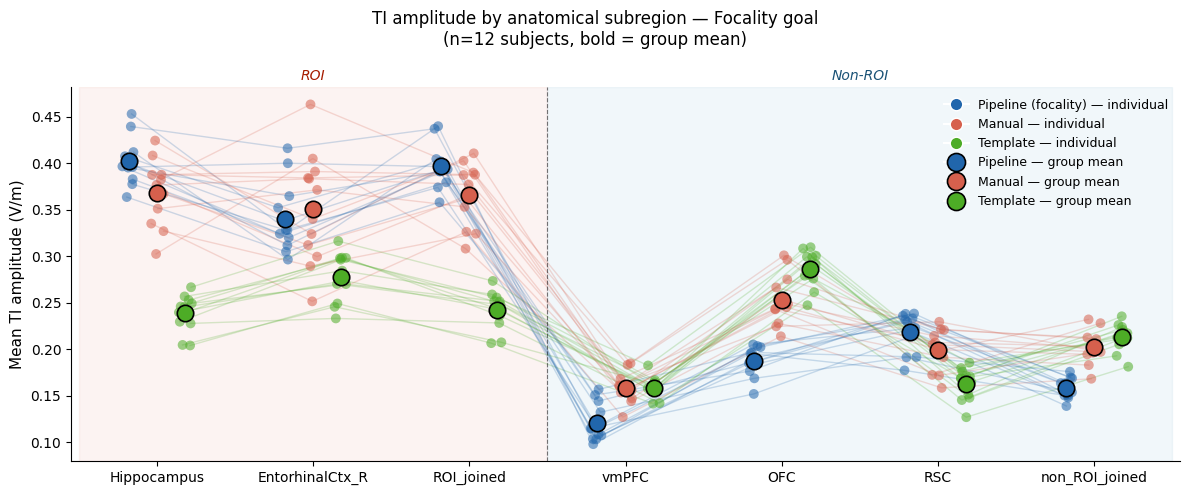

Saved → D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\group_TI_subparts_focality.png


In [18]:
# ── Cell 6.4: Subregion jitter plot ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

if not subpart_data:
    raise RuntimeError('subpart_data is empty — run Cell 6.3 first.')

COLOR_PL   = '#2166ac'
COLOR_MN   = '#d6604d'
COLOR_TM   = '#4dac26'
OFFSET     = 0.18
JITTER     = 0.045
rng        = np.random.default_rng(42)

subgroup_names = list(ALL_SUBGROUPS.keys())
n_groups       = len(subgroup_names)
n_roi          = len(ROI_SUBGROUPS)
n_subj         = len(subpart_data)

fig, ax = plt.subplots(figsize=(12, 5))

ax.axvspan(-0.5,          n_roi - 0.5,    alpha=0.07, color='#d6604d', zorder=0)
ax.axvspan(n_roi - 0.5,  n_groups - 0.5, alpha=0.07, color='#4393c3', zorder=0)

# Storage for subject lines: shape (n_subj, n_subgroups, 2)
pos_pl = np.full((n_subj, n_groups, 2), np.nan)
pos_mn = np.full((n_subj, n_groups, 2), np.nan)
pos_tm = np.full((n_subj, n_groups, 2), np.nan)

for gi, sg in enumerate(subgroup_names):
    pl_vals = [d[f'{sg}_pipeline'] for d in subpart_data]
    mn_vals = [d[f'{sg}_manual']   for d in subpart_data]
    tm_vals = [d[f'{sg}_template'] for d in subpart_data]

    for si, (pv, mv, tv) in enumerate(zip(pl_vals, mn_vals, tm_vals)):
        jx = rng.uniform(-JITTER, JITTER)
        xp = gi - OFFSET + jx
        if not np.isnan(pv):
            ax.scatter(xp, pv, color=COLOR_PL, alpha=0.55, s=50, zorder=3, edgecolors='none')
            pos_pl[si, gi] = [xp, pv]

        jx = rng.uniform(-JITTER, JITTER)
        xm = gi + jx
        if not np.isnan(mv):
            ax.scatter(xm, mv, color=COLOR_MN, alpha=0.55, s=50, zorder=3, edgecolors='none')
            pos_mn[si, gi] = [xm, mv]

        jx = rng.uniform(-JITTER, JITTER)
        xt = gi + OFFSET + jx
        if not np.isnan(tv):
            ax.scatter(xt, tv, color=COLOR_TM, alpha=0.55, s=50, zorder=3, edgecolors='none')
            pos_tm[si, gi] = [xt, tv]

    gm_pl = np.nanmean(pl_vals)
    gm_mn = np.nanmean(mn_vals)
    gm_tm = np.nanmean(tm_vals)
    ax.scatter(gi - OFFSET, gm_pl, color=COLOR_PL, s=140, zorder=5,
               edgecolors='black', linewidths=1.2)
    ax.scatter(gi,          gm_mn, color=COLOR_MN, s=140, zorder=5,
               edgecolors='black', linewidths=1.2)
    ax.scatter(gi + OFFSET, gm_tm, color=COLOR_TM, s=140, zorder=5,
               edgecolors='black', linewidths=1.2)

# Per-subject connecting lines (drawn after all dots, so dots are on top)
for si in range(n_subj):
    for pos, color in [(pos_pl[si], COLOR_PL),
                       (pos_mn[si], COLOR_MN),
                       (pos_tm[si], COLOR_TM)]:
        valid = ~np.isnan(pos[:, 0])
        if valid.sum() > 1:
            ax.plot(pos[valid, 0], pos[valid, 1],
                    color=color, alpha=0.22, lw=1.0, zorder=2)

ax.axvline(n_roi - 0.5, color='black', lw=0.8, ls='--', alpha=0.5)
y_top = ax.get_ylim()[1]
ax.text(n_roi / 2 - 0.5,                    y_top * 1.01, 'ROI',
        ha='center', va='bottom', fontsize=10, style='italic', color='#a61c00')
ax.text(n_roi + (n_groups - n_roi)/2 - 0.5, y_top * 1.01, 'Non-ROI',
        ha='center', va='bottom', fontsize=10, style='italic', color='#1a5276')

ax.set_xticks(range(n_groups))
ax.set_xticklabels(subgroup_names, fontsize=10)
ax.set_xlim(-0.55, n_groups - 0.45)
ax.set_ylabel('Mean TI amplitude (V/m)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

leg = [
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_PL,
                  markersize=9,  label=f'Pipeline ({GOAL}) — individual'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_MN,
                  markersize=9,  label='Manual — individual'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_TM,
                  markersize=9,  label='Template — individual'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_PL,
                  markersize=13, markeredgecolor='black', markeredgewidth=1.2,
                  label='Pipeline — group mean'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_MN,
                  markersize=13, markeredgecolor='black', markeredgewidth=1.2,
                  label='Manual — group mean'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=COLOR_TM,
                  markersize=13, markeredgecolor='black', markeredgewidth=1.2,
                  label='Template — group mean'),
]
ax.legend(handles=leg, fontsize=9, frameon=False, loc='upper right')

plt.suptitle(
    f'TI amplitude by anatomical subregion — {GOAL.capitalize()} goal\n'
    f'(n={len(subpart_data)} subjects, bold = group mean)',
    fontsize=12,
)
plt.tight_layout()
out_png = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                        f'group_TI_subparts_{GOAL}.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_png}')


  sub-73T01: registering 61 electrodes ...
  sub-73T02: registering 61 electrodes ...
  sub-73T03: registering 61 electrodes ...
  sub-73T04: registering 61 electrodes ...
  sub-73T05: registering 61 electrodes ...
  sub-73T06: registering 61 electrodes ...
  sub-73T07: registering 61 electrodes ...
  sub-73T09: registering 61 electrodes ...
  sub-73T10: registering 61 electrodes ...
  sub-73T11: registering 61 electrodes ...
  sub-73T12: registering 61 electrodes ...
  sub-73T14: registering 61 electrodes ...
  Done.


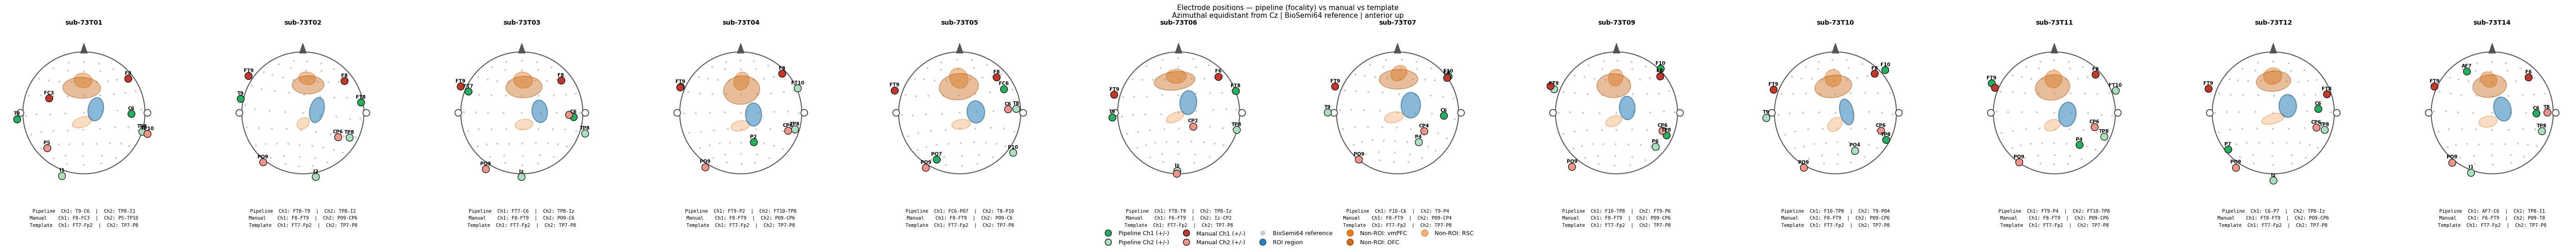

Saved -> D:/MINDS_Project_Karim/BIDS_TI_Toolbox\derivatives\SimNIBS\electrode_positions_azeq.png


In [19]:
# ── Cell 6.5: Electrode positions — azimuthal equidistant projection ──────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from simnibs import mesh_io
from simnibs.utils.transformations import mni2subject_coords

if not group_stats:
    raise RuntimeError('group_stats is empty — run Cell 6.1 first.')

if '_jurak' not in dir():
    import csv as _csv, pathlib as _pl, simnibs as _smb
    _jurak_csv = (_pl.Path(_smb.__file__).parent
                  / 'resources' / 'ElectrodeCaps_MNI' / 'EEG10-10_UI_Jurak_2007.csv')
    _jurak = {}
    with open(_jurak_csv, newline='') as _f:
        for _row in _csv.reader(_f):
            if _row and _row[0] in ('Electrode', 'ReferenceElectrode'):
                _jurak[_row[4].strip()] = np.array([float(_row[1]),
                                                     float(_row[2]),
                                                     float(_row[3])])

_B64 = ['Fp1','AF7','AF3','F1','F3','F5','F7','FT7','FC5','FC3','FC1',
        'C1','C3','C5','T7','TP7','CP5','CP3','CP1','P1','P3','P5','P7',
        'PO7','PO3','O1','Oz','POz','Pz','CPz','Fpz',
        'Fp2','AF8','AF4','AFz','Fz','F2','F4','F6','F8','FT8','FC6',
        'FC4','FC2','FCz','Cz','C2','C4','C6','T8','TP8','CP6','CP4',
        'CP2','P2','P4','P6','P8','PO8','PO4','O2']
BIOSEMI64 = [n for n in _B64 if n in _jurak]

EL_COLORS = {
    'pipeline_ch1':  '#27ae60',
    'pipeline_ch2':  '#a9dfbf',
    'manual_ch1':    '#c0392b',
    'manual_ch2':    '#f1948a',
    'template_ch1':  '#8e44ad',
    'template_ch2':  '#d2b4de',
}
NR_COLORS = {
    'vmPFC': ('#e67e22', '#d35400'),   # face, edge — orange
    'OFC':   ('#ca6f1e', '#a04000'),   # darker terracotta
    'RSC':   ('#f0b27a', '#e67e22'),   # light amber
}
NR_LABELS = {
    'vmPFC': VMPC_LBL,
    'OFC':   OFC_LBL,
    'RSC':   RSC_LBL,
}


def azeq_project(positions_3d, head_center, cz_3d):
    cz_vec = cz_3d - head_center
    cz_hat = cz_vec / np.linalg.norm(cz_vec)
    ant    = np.array([0., 1., 0.])
    up     = ant - np.dot(ant, cz_hat) * cz_hat
    up    /= np.linalg.norm(up)
    right  = np.cross(up, cz_hat)
    right /= np.linalg.norm(right)
    xy = np.zeros((len(positions_3d), 2))
    for i, p in enumerate(positions_3d):
        v      = p - head_center
        v_norm = np.linalg.norm(v)
        if v_norm < 1e-10:
            continue
        v_hat  = v / v_norm
        cos_th = float(np.clip(np.dot(v_hat, cz_hat), -1., 1.))
        theta  = np.arccos(cos_th)
        tang   = v_hat - cos_th * cz_hat
        tnorm  = np.linalg.norm(tang)
        if tnorm < 1e-10:
            xy[i] = [0., 0.]
            continue
        t_hat    = tang / tnorm
        xy[i, 0] = np.dot(t_hat, right) * theta
        xy[i, 1] = np.dot(t_hat, up)    * theta
    return xy

def _register_batch(subject, names, project_dir):
    m2m   = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                          f'sub-{subject}', f'm2m_{subject}')
    mni   = np.array([_jurak[n] for n in names])
    subj  = mni2subject_coords(mni, m2m)
    msh   = mesh_io.read_msh(os.path.join(m2m, f'{subject}.msh'))
    scalp = msh.crop_mesh(tags=[5]).nodes.node_coord
    def snap(c):
        return scalp[np.argmin(np.linalg.norm(scalp - c, axis=1))]
    return {n: snap(c) for n, c in zip(names, subj)}, scalp

# ── Plot ───────────────────────────────────────────────────────────────────────
n_sub = len(group_stats)
fig, axes = plt.subplots(1, n_sub, figsize=(4.8 * n_sub, 5.5))
if n_sub == 1:
    axes = [axes]

def _split(ch_str):
    p = ch_str.split('-')
    return p[0], p[1]

sd_by_subj = {d['subject']: d for d in subpart_data} if 'subpart_data' in dir() else {}

for ax, s in zip(axes, group_stats):
    subject = s['subject']
    print(f'  sub-{subject}: registering {len(BIOSEMI64)} electrodes ...', flush=True)

    pl1p, pl1m = _split(s['pipeline_ch1'])
    pl2p, pl2m = _split(s['pipeline_ch2'])
    mn1p, mn1m = _split(s['manual_ch1'])
    mn2p, mn2m = _split(s['manual_ch2'])
    tm1p, tm1m = _split(s['template_ch1'])
    tm2p, tm2m = _split(s['template_ch2'])

    sel = list(dict.fromkeys([pl1p, pl1m, pl2p, pl2m,
                               mn1p, mn1m, mn2p, mn2m,
                               tm1p, tm1m, tm2p, tm2m]))
    all_names = list(dict.fromkeys(BIOSEMI64 + [n for n in sel if n not in BIOSEMI64]))
    coord_map, scalp_nodes = _register_batch(subject, all_names, PROJECT_DIR)

    b64_pos  = np.array([coord_map[n] for n in BIOSEMI64])
    cz_pos   = coord_map['Cz']
    head_ctr = b64_pos.mean(axis=0)

    b64_xy = azeq_project(b64_pos, head_ctr, cz_pos)
    r      = np.max(np.linalg.norm(b64_xy, axis=1)) * 1.05

    th = np.linspace(0, 2 * np.pi, 300)
    ax.plot(r * np.cos(th), r * np.sin(th), color='#555555', lw=1.5, zorder=1)
    nose = plt.Polygon([[0, r*1.14], [-r*0.055, r*0.98], [r*0.055, r*0.98]],
                        closed=True, fc='#555555', ec='#555555', zorder=1)
    ax.add_patch(nose)
    for ex in [-r*1.04, r*1.04]:
        ax.add_patch(plt.Circle((ex, 0), r*0.055, fc='white',
                                ec='#555555', lw=1.5, zorder=1))

    ax.scatter(b64_xy[:, 0], b64_xy[:, 1],
               s=10, c='#cccccc', zorder=2, edgecolors='none')

    # template lowest priority (drawn first), manual highest (drawn last)
    draw_order = [
        # ('template_ch2', [tm2p, tm2m]),
        # ('template_ch1', [tm1p, tm1m]),
        ('pipeline_ch2', [pl2p, pl2m]),
        ('pipeline_ch1', [pl1p, pl1m]),
        ('manual_ch2',   [mn2p, mn2m]),
        ('manual_ch1',   [mn1p, mn1m]),
    ]
    labelled = set()
    for cat, names_list in draw_order:
        # also add a small jitter to avoid exact overlap of plus/minus electrodes
        jitter = np.random.normal(0, 0.09, (len(names_list), 2))
        color = EL_COLORS[cat]
        for i, name in enumerate(names_list):
            xy2d = azeq_project(np.array([coord_map[name]]), head_ctr, cz_pos)[0] + jitter[i]
            ax.scatter(xy2d[0], xy2d[1], color=color, s=130, zorder=5,
                       edgecolors='black', linewidths=0.9)
            if name not in labelled:
                ax.annotate(name, xy=xy2d, fontsize=7.5, fontweight='bold',
                            ha='center', va='bottom',
                            xytext=(0, 5), textcoords='offset points', zorder=6)
                labelled.add(name)

    # ROI ellipse
    sd = sd_by_subj.get(subject)
    if sd and 'centroids' in sd:
        from matplotlib.patches import Ellipse as MplEllipse
        roi_pts = sd['centroids'][sd['roi_mask']]
        step    = max(1, len(roi_pts) // 200)
        sample  = roi_pts[::step]
        proj_2d = []
        for pt in sample:
            above = scalp_nodes[scalp_nodes[:, 2] > pt[2]]
            if len(above) == 0:
                above = scalp_nodes
            xy_d  = np.linalg.norm(above[:, :2] - pt[:2], axis=1)
            sp    = above[np.argmin(xy_d)]
            proj_2d.append(azeq_project(sp[None], head_ctr, cz_pos)[0])
        proj_2d  = np.array(proj_2d)
        center   = proj_2d.mean(axis=0)
        cov      = np.cov(proj_2d.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        angle  = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
        width  = 4 * np.sqrt(eigvals[-1])
        height = 4 * np.sqrt(eigvals[-2])
        ax.add_patch(MplEllipse(center, width=width, height=height, angle=angle,
                                fc='#2980b9', ec='#1a5276',
                                alpha=0.55, zorder=3, lw=1.5))

        # Non-ROI — one ellipse per anatomical group
        elm_lbl_nr = _atlas_elm_labels(subject, PROJECT_DIR, sd['centroids'])
        for grp_name, (fc, ec) in NR_COLORS.items():
            grp_mask  = np.isin(elm_lbl_nr, list(NR_LABELS[grp_name])) & sd['non_roi_mask']
            if not grp_mask.any():
                continue
            grp_pts   = sd['centroids'][grp_mask]
            step_nr   = max(1, len(grp_pts) // 200)
            sample_nr = grp_pts[::step_nr]
            proj_nr   = []
            for pt in sample_nr:
                above = scalp_nodes[scalp_nodes[:, 2] > pt[2]]
                if len(above) == 0:
                    above = scalp_nodes
                xy_d  = np.linalg.norm(above[:, :2] - pt[:2], axis=1)
                sp    = above[np.argmin(xy_d)]
                proj_nr.append(azeq_project(sp[None], head_ctr, cz_pos)[0])
            proj_nr    = np.array(proj_nr)
            center_nr  = proj_nr.mean(axis=0)
            cov_nr     = np.cov(proj_nr.T)
            eigvals_nr, eigvecs_nr = np.linalg.eigh(cov_nr)
            angle_nr   = np.degrees(np.arctan2(eigvecs_nr[1, -1], eigvecs_nr[0, -1]))
            width_nr   = 4 * np.sqrt(eigvals_nr[-1])
            height_nr  = 4 * np.sqrt(eigvals_nr[-2])
            ax.add_patch(MplEllipse(center_nr, width=width_nr, height=height_nr,
                                    angle=angle_nr, fc=fc, ec=ec,
                                    alpha=0.45, zorder=2, lw=1.2))

    else:
        print(f'    [warn] no centroid data for sub-{subject} — run Cell 6.3 first')

    ax.set_aspect('equal')
    pad = r * 0.3
    ax.set_xlim(-r - pad, r + pad)
    ax.set_ylim(-r - pad, r + pad * 1.3)
    ax.set_title(f'sub-{subject}', fontsize=10, fontweight='bold', pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    ch_text = (
        f'Pipeline  Ch1: {pl1p}-{pl1m}  |  Ch2: {pl2p}-{pl2m}\n'
        f'Manual    Ch1: {mn1p}-{mn1m}  |  Ch2: {mn2p}-{mn2m}\n'
        f'Template  Ch1: {tm1p}-{tm1m}  |  Ch2: {tm2p}-{tm2m}'
    )
    ax.text(0.5, -0.10, ch_text, transform=ax.transAxes,
            ha='center', va='top', fontsize=7.5, linespacing=1.6,
            family='monospace')

print('  Done.')

leg = [
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=EL_COLORS['pipeline_ch1'],
                  markersize=10, markeredgecolor='black', label='Pipeline Ch1 (+/-)'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=EL_COLORS['pipeline_ch2'],
                  markersize=10, markeredgecolor='black', label='Pipeline Ch2 (+/-)'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=EL_COLORS['manual_ch1'],
                  markersize=10, markeredgecolor='black', label='Manual Ch1 (+/-)'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=EL_COLORS['manual_ch2'],
                  markersize=10, markeredgecolor='black', label='Manual Ch2 (+/-)'),
    # mlines.Line2D([], [], marker='o', color='w', markerfacecolor=EL_COLORS['template_ch1'],
    #               markersize=10, markeredgecolor='black', label='Template Ch1 (+/-)'),
    # mlines.Line2D([], [], marker='o', color='w', markerfacecolor=EL_COLORS['template_ch2'],
                #   markersize=10, markeredgecolor='black', label='Template Ch2 (+/-)'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#cccccc',
                  markersize=8,  markeredgecolor='none',  label='BioSemi64 reference'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#2980b9',
                  markersize=10, markeredgecolor='#1a5276', label='ROI region'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=NR_COLORS['vmPFC'][0],
                  markersize=10, markeredgecolor=NR_COLORS['vmPFC'][1], label='Non-ROI: vmPFC'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=NR_COLORS['OFC'][0],
                  markersize=10, markeredgecolor=NR_COLORS['OFC'][1],  label='Non-ROI: OFC'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=NR_COLORS['RSC'][0],
                  markersize=10, markeredgecolor=NR_COLORS['RSC'][1],  label='Non-ROI: RSC'),

]
fig.legend(handles=leg, loc='lower center', ncol=5, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, 0.0))
plt.suptitle(
    f'Electrode positions — pipeline ({GOAL}) vs manual vs template\n'
    f'Azimuthal equidistant from Cz | BioSemi64 reference | anterior up',
    fontsize=11,
)
plt.tight_layout(rect=[0, 0.16, 1, 1])
out_png = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS', 'electrode_positions_azeq.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_png}')
